# WV Quantile Embedding Benchmark

This notebook revises the WorldValue benchmark so the learned question-level predictors are not treated as plug-in estimates of the human target `p`. Instead, their out-of-fold predictions are interpreted as learned simulator-side outputs `q_tilde`, and only after those `q_tilde` objects are constructed do we pass them through the same calibrated discrepancy pipeline used for the LLM simulators in [WV_quantile_construction.ipynb](WV_quantile_construction.ipynb).

Top-level summary

- Reused workflow: retained 235-question subset, simulator bundle, `full` / `full_summary`, adaptive `gamma_j`, and calibrated pseudo-discrepancy construction are taken from the same pipeline used in [WV_quantile_construction.ipynb](WV_quantile_construction.ipynb).
- Human target source: the notebook prefers the finite-sample retained-qid human target used for the calibrated benchmark setting, with full-data objects kept only as diagnostics and fallback checks.
- Step 1, learned q construction: two shared cross-fitted predictors are built. The main question-embedding baseline uses question embeddings and metadata only, while the optional simulator-augmented baseline augments those features with simulator-side `qhat` features computed directly from simulator samples.
- Step 2, robust benchmarking: after those learned `q_tilde` objects are produced, they are treated exactly like simulator outputs and benchmarked under the same robust confidence-set construction already used for the other simulators.
- Model-family diagnostics: the notebook also compares kernel ridge against kNN so we can see whether local-neighborhood structure in the embedding space is competitive with the smoother kernel baseline.
- Quantile indexing: all simulator curves, including the learned baselines, use the same theorem-shifted quantile index.


## SECTION 1 — Preparation

This section keeps the setup, repo discovery, data loading, real-data target selection, and question-feature construction in one place so the benchmark reads as a single preparation workflow.

Keep the object names and path conventions close to the current WorldValue quantile notebook so the benchmark is a natural extension rather than a separate workflow.


Embedding provenance

This notebook is fully runnable from the committed cached embedding artifact in the reproduction tree. For transparency, a commented reproduction snippet adapted from [WV_simulator_selection.ipynb](WV_simulator_selection.ipynb) is included below so readers can see how the cached question embeddings were originally generated.


In [1]:
# Commented embedding-generation reference adapted from WV_simulator_selection.ipynb.
# This notebook does not execute the API call by default because the cached artifact is
# already committed at:
#   data/worldvalue/simulator_selector/wvs_qid_embeddings_openai_text-embedding-3-small.pkl
#
# To regenerate that artifact, uncomment and run a block like this in the same
# paper_reproduction/worldvalue_quantile environment.
#
# from openai import OpenAI
# import os
# import pickle
# import numpy as np
# import pandas as pd
# from pathlib import Path
#
# REPRO_ROOT = find_repo_root(Path.cwd())
# embed_model = "text-embedding-3-small"
# batch_size = 32
# api_key = os.getenv("OPENAI_API_KEY", "").strip()
# if not api_key:
#     raise RuntimeError("OPENAI_API_KEY is required to regenerate the cached embedding artifact.")
#
# client = OpenAI(api_key=api_key)
#
# def batched(seq, n):
#     for i in range(0, len(seq), n):
#         yield seq[i:i+n]
#
# qid_text_df = question_df[["qid", "question_text", "category", "question_representation"]].copy()
# qid_text_df = qid_text_df.rename(columns={"question_representation": "embed_text"})
#
# vectors = []
# for batch in batched(qid_text_df["embed_text"].tolist(), batch_size):
#     resp = client.embeddings.create(model=embed_model, input=batch)
#     vectors.extend([row.embedding for row in resp.data])
#
# qid_text_df["embedding"] = [np.asarray(v, dtype=float).tolist() for v in vectors]
# out_path = REPRO_ROOT / "data/worldvalue/simulator_selector/wvs_qid_embeddings_openai_text-embedding-3-small.pkl"
# with open(out_path, "wb") as f:
#     pickle.dump(qid_text_df[["qid", "question_text", "category", "embed_text", "embedding"]], f)
# print(f"saved: {out_path}")


In [2]:
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.metrics import mean_absolute_error, mean_squared_error, pairwise_distances
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.feature_extraction.text import TfidfVectorizer

from wvs_notebook_helpers import (
    ensure_worldvalue_inputs,
    filter_mapping_to_questions,
    find_repo_root,
    install_numpy_pickle_compat,
)
from simfidelity_utils import compute_pseudo_delta, empirical_quantile_curve

install_numpy_pickle_compat()
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

NOTEBOOK_DIR = Path.cwd().resolve()
REPRO_ROOT = find_repo_root(NOTEBOOK_DIR)
ensure_worldvalue_inputs(REPRO_ROOT)
OUTPUT_DIR = NOTEBOOK_DIR / "output_embedding_benchmark"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = NOTEBOOK_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_PATHS = {
    "source_notebook": NOTEBOOK_DIR / "WV_quantile_construction.ipynb",
    "retained_questions": REPRO_ROOT / "data/worldvalue/retained_questions_235.json",
    "full_human": REPRO_ROOT / "data/worldvalue/full_population_response_clean.pkl",
    "full_summary": REPRO_ROOT / "data/worldvalue/full_population_response_summary.pkl",
    "actual_human": REPRO_ROOT / "data/worldvalue/population_response_clean.pkl",
    "question_metadata": REPRO_ROOT / "data/worldvaluesbench/dataset_construction/question_metadata.json",
    "codebook": REPRO_ROOT / "data/worldvaluesbench/dataset_construction/codebook.json",
    "value_questions": REPRO_ROOT / "data/worldvaluesbench/dataset_construction/probe_set_construction/value_questions.json",
    "cached_openai_embeddings": REPRO_ROOT / "data/worldvalue/simulator_selector/wvs_qid_embeddings_openai_text-embedding-3-small.pkl",
}

display(
    pd.DataFrame(
        {
            "name": list(SOURCE_PATHS.keys()),
            "path": [str(path.relative_to(REPRO_ROOT)) for path in SOURCE_PATHS.values()],
            "exists": [path.exists() for path in SOURCE_PATHS.values()],
        }
    )
)
print("Note: this notebook prefers the repo's cached OpenAI embedding artifact when it fully covers the retained qids.")


,name,path,exists
0,source_notebook,worldvalue_quantile/WV_quantile_construction.i...,True
1,retained_questions,data/worldvalue/retained_questions_235.json,True
2,full_human,data/worldvalue/full_population_response_clean...,True
3,full_summary,data/worldvalue/full_population_response_summa...,True
4,actual_human,data/worldvalue/population_response_clean.pkl,True
5,question_metadata,data/worldvaluesbench/dataset_construction/que...,True
6,codebook,data/worldvaluesbench/dataset_construction/cod...,True
7,value_questions,data/worldvaluesbench/dataset_construction/pro...,True
8,cached_openai_embeddings,data/worldvalue/simulator_selector/wvs_qid_emb...,True


Note: this notebook prefers the repo's cached OpenAI embedding artifact when it fully covers the retained qids.


### Load the same WorldValue objects as the calibrated notebook


In [3]:
with open(SOURCE_PATHS["retained_questions"], "r", encoding="utf-8") as f:
    retained_questions = [str(q) for q in json.load(f)]
retained_qid_set = set(retained_questions)

def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

gpt4o = filter_mapping_to_questions(
    load_pickle(REPRO_ROOT / "data/worldvalue/synthetic answers/clean/synthetic_answers_clean_gpt4o.pkl"),
    retained_questions,
)
gpt5m = filter_mapping_to_questions(
    load_pickle(REPRO_ROOT / "data/worldvalue/synthetic answers/clean/synthetic_answers_clean_gpt-5-mini.pkl"),
    retained_questions,
)
llama = filter_mapping_to_questions(
    load_pickle(REPRO_ROOT / "data/worldvalue/synthetic answers/clean/synthetic_answers_clean_llama-3.3.pkl"),
    retained_questions,
)
qwen = filter_mapping_to_questions(
    load_pickle(REPRO_ROOT / "data/worldvalue/synthetic answers/clean/synthetic_answers_clean_Qwen3-235B.pkl"),
    retained_questions,
)
uniform_benchmark = filter_mapping_to_questions(
    load_pickle(REPRO_ROOT / "data/worldvalue/synthetic answers/clean/uniform_benchmark.pkl"),
    retained_questions,
)

actual = filter_mapping_to_questions(load_pickle(SOURCE_PATHS["actual_human"]), retained_questions)
full = filter_mapping_to_questions(load_pickle(SOURCE_PATHS["full_human"]), retained_questions)
full_summary = load_pickle(SOURCE_PATHS["full_summary"])

with open(SOURCE_PATHS["question_metadata"], "r", encoding="utf-8") as f:
    question_metadata = json.load(f)
with open(SOURCE_PATHS["codebook"], "r", encoding="utf-8") as f:
    codebook = json.load(f)
if SOURCE_PATHS["value_questions"].exists():
    with open(SOURCE_PATHS["value_questions"], "r", encoding="utf-8") as f:
        value_questions = json.load(f)
else:
    warnings.warn("value_questions.json is unavailable in the reproduction tree; proceeding without it.")
    value_questions = {}

simulators = {
    "GPT4o": gpt4o,
    "Llama": llama,
    "GPT5mini": gpt5m,
    "Qwen3": qwen,
    "Uniform": uniform_benchmark,
}
SIM_ORDER = ["GPT4o", "GPT5mini", "Llama", "Qwen3", "Uniform"]

QUESTION_EMBEDDING_BASELINE_NAME = "Kernel-Ridge Embedding Baseline"
SIMULATOR_AUGMENTED_BASELINE_NAME = "Kernel-Ridge Simulator-Augmented Baseline"
QUESTION_EMBEDDING_COLOR = "#8c564b"
SIMULATOR_AUGMENTED_COLOR = "#e377c2"
QUESTION_EMBEDDING_LINESTYLE = "-."
SIMULATOR_AUGMENTED_LINESTYLE = ":"
LEARNED_BASELINE_LINEWIDTH = 3.2

def learned_baseline_name_from_model_types(model_types):
    unique_types = sorted({str(x) for x in model_types if pd.notna(x)})
    if unique_types == ["kernel_ridge_rbf"]:
        return "Kernel ridge"
    if unique_types == ["knn_cosine"]:
        return "kNN"
    return "Mixed model family"

def pretty_model_family(model_type: str) -> str:
    if str(model_type) == "kernel_ridge_rbf":
        return "Kernel ridge"
    if str(model_type) == "knn_cosine":
        return "kNN"
    return str(model_type)

SIM_COLOR_MAP = {
    "GPT4o": "C0",
    "Llama": "C1",
    "GPT5mini": "C2",
    "Uniform": "C3",
    "Qwen3": "C4",
}

full_summary_df = full_summary.copy()
if "qid" not in full_summary_df.columns:
    full_summary_df = full_summary_df.reset_index()
if "index" in full_summary_df.columns and "qid" not in full_summary_df.columns:
    full_summary_df = full_summary_df.rename(columns={"index": "qid"})
full_summary_df["qid"] = full_summary_df["qid"].astype(str).str.strip()
full_summary_df = full_summary_df[full_summary_df["qid"].isin(retained_qid_set)].copy()
full_summary_df = full_summary_df.set_index("qid").reindex(retained_questions).reset_index()

display(
    pd.DataFrame(
        {
            "object": ["retained_questions", "full", "actual", *SIM_ORDER, "full_summary_df"],
            "n_items": [len(retained_questions), len(full), len(actual), *(len(simulators[s]) for s in SIM_ORDER), len(full_summary_df)],
        }
    )
)
print("The learned baseline simulators are added later, after cross-fitted q_tilde predictions are constructed.")


,object,n_items
0,retained_questions,235
1,full,235
2,actual,235
3,GPT4o,235
4,GPT5mini,235
5,Llama,235
6,Qwen3,235
7,Uniform,235
8,full_summary_df,235


The learned baseline simulators are added later, after cross-fitted q_tilde predictions are constructed.


### Select the strongest human-side real-data target

The learned baseline is supervised on the strongest human-side real-data target available in the repo, trained only on held-in folds, and then evaluated on held-out folds to produce out-of-fold simulator-style outputs `q_tilde`.

Selection hierarchy

- First choice: raw full-data human responses for the retained qids
- Second choice: full-data question-level aggregates
- Last resort: smaller-sample human targets

Once `q_tilde` is produced, the rest of the benchmark is unchanged: it is treated as another simulator output and compared through the same calibrated discrepancy pipeline as the LLM simulators.


In [4]:
def summarize_response_mapping(resp_dict, source_name):
    rows = []
    for qid in retained_questions:
        raw = resp_dict.get(qid, [])
        arr = np.asarray(getattr(raw, "values", raw), dtype=float)
        arr = arr[np.isfinite(arr)]
        rows.append(
            {
                "qid": qid,
                "source_name": source_name,
                "n_valid": int(arr.size),
                "mean": float(arr.mean()) if arr.size else np.nan,
                "std": float(arr.std(ddof=1)) if arr.size >= 2 else np.nan,
            }
        )
    return pd.DataFrame(rows)

full_raw_target_df = summarize_response_mapping(full, "full_raw_responses")
actual_target_df = summarize_response_mapping(actual, "actual_smaller_sample")
full_summary_target_df = full_summary_df.rename(columns={"source_name": "unused"}).copy()
full_summary_target_df["source_name"] = "full_summary_aggregate"
if "n_valid" not in full_summary_target_df.columns:
    full_summary_target_df["n_valid"] = np.nan
full_summary_target_df = full_summary_target_df[["qid", "source_name", "n_valid", "mean", "std"]]

target_candidates = []
for candidate_name, candidate_df in [
    ("full_raw_responses", full_raw_target_df),
    ("full_summary_aggregate", full_summary_target_df),
    ("actual_smaller_sample", actual_target_df),
]:
    target_candidates.append(
        {
            "candidate_name": candidate_name,
            "n_qids_with_target": int(candidate_df["mean"].notna().sum()),
            "min_n_valid": float(np.nanmin(candidate_df["n_valid"])) if candidate_df["n_valid"].notna().any() else np.nan,
            "max_n_valid": float(np.nanmax(candidate_df["n_valid"])) if candidate_df["n_valid"].notna().any() else np.nan,
        }
    )

target_selection_df = pd.DataFrame(target_candidates)
if actual_target_df["mean"].notna().sum() == len(retained_questions):
    selected_target_df = actual_target_df.copy()
    selected_target_source = "actual_smaller_sample"
elif full_summary_target_df["mean"].notna().sum() == len(retained_questions):
    selected_target_df = full_summary_target_df.copy()
    selected_target_source = "full_summary_aggregate"
else:
    selected_target_df = full_raw_target_df.copy()
    selected_target_source = "full_raw_responses"

selected_target_df = selected_target_df.rename(
    columns={
        "mean": "human_target",
        "std": "human_target_std",
        "n_valid": "human_target_n",
    }
)
selected_target_df["human_target_source"] = selected_target_source

full_target_consistency_df = full_raw_target_df.merge(
    full_summary_target_df.rename(
        columns={
            "mean": "summary_mean",
            "std": "summary_std",
            "n_valid": "summary_n_valid",
        }
    ),
    on="qid",
    how="inner",
)
full_target_consistency_df["abs_mean_diff"] = (
    full_target_consistency_df["mean"] - full_target_consistency_df["summary_mean"]
).abs()
full_target_consistency_summary = pd.DataFrame(
    [
        {
            "selected_target_source": selected_target_source,
            "max_abs_mean_diff_raw_vs_summary": float(full_target_consistency_df["abs_mean_diff"].max()),
            "mean_abs_mean_diff_raw_vs_summary": float(full_target_consistency_df["abs_mean_diff"].mean()),
        }
    ]
)

target_selection_df.to_csv(OUTPUT_DIR / "human_target_source_summary.csv", index=False)
full_target_consistency_summary.to_csv(OUTPUT_DIR / "human_target_consistency_summary.csv", index=False)

display(target_selection_df)
display(full_target_consistency_summary)
print("Selected predictive target source:", selected_target_source)


,candidate_name,n_qids_with_target,min_n_valid,max_n_valid
0,full_raw_responses,235,68524.0,96066.0
1,full_summary_aggregate,235,68524.0,96066.0
2,actual_smaller_sample,235,350.0,500.0


,selected_target_source,max_abs_mean_diff_raw_vs_summary,mean_abs_mean_diff_raw_vs_summary
0,actual_smaller_sample,0.0,0.0


Selected predictive target source: actual_smaller_sample


### Build the question-level feature dataframe

The main learned baseline uses question semantics and metadata only. Existing simulator outputs `qhat` are deliberately excluded from these features so the learned baseline remains a standalone simulator-side construction rather than a simulator-assisted plug-in estimate.


In [5]:
def _safe_float(value):
    if value in ("", None):
        return np.nan
    try:
        return float(value)
    except Exception:
        return np.nan

def _clean_choices(choices):
    if not isinstance(choices, dict):
        return {}

    def sort_key(item):
        key = str(item[0])
        try:
            return (0, float(key))
        except Exception:
            return (1, key)

    out = {}
    for raw_key, raw_val in sorted(choices.items(), key=sort_key):
        key = str(raw_key)
        if key.startswith("-"):
            continue
        val = str(raw_val).strip()
        if val:
            out[key] = val
    return out

question_rows = []
for qid in retained_questions:
    meta = question_metadata.get(qid, {})
    cb = codebook.get(qid, {})
    choice_dict = _clean_choices(cb.get("choices"))
    question_rows.append(
        {
            "qid": qid,
            "question_text": str(meta.get("question") or cb.get("question") or qid).strip(),
            "short_label": str(cb.get("question") or "").strip(),
            "question_instruction": str(cb.get("question_instruction") or "").strip(),
            "answer_option_text": " | ".join([f"{k} = {v}" for k, v in choice_dict.items()]),
            "category": str(meta.get("category") or "Unknown").strip(),
            "use_case": str(meta.get("use_case") or "").strip(),
            "answer_data_type": str(meta.get("answer_data_type") or cb.get("type") or "").strip(),
            "answer_scale_min": _safe_float(meta.get("answer_scale_min")),
            "answer_scale_max": _safe_float(meta.get("answer_scale_max")),
            "n_answer_choices": len(choice_dict),
            "in_value_questions_json": qid in set(value_questions.keys()) if isinstance(value_questions, dict) else qid in set(value_questions),
        }
    )

question_df = pd.DataFrame(question_rows).merge(
    selected_target_df[["qid", "human_target", "human_target_std", "human_target_n", "human_target_source"]],
    on="qid",
    how="left",
)
question_df["scale_span"] = question_df["answer_scale_max"] - question_df["answer_scale_min"]
question_df["question_representation"] = (
    "Category: " + question_df["category"].fillna("Unknown") + "\n"
    + "Question: " + question_df["question_text"].fillna(question_df["qid"]) + "\n"
    + np.where(
        question_df["question_instruction"].fillna("").ne(""),
        "Instruction: " + question_df["question_instruction"].fillna("") + "\n",
        "",
    )
    + np.where(
        question_df["answer_option_text"].fillna("").ne(""),
        "Answer options: " + question_df["answer_option_text"].fillna(""),
        "Answer options: unavailable",
    )
)

missing_text_mask = question_df["question_text"].fillna("").str.strip().eq("")
missing_options_mask = question_df["answer_option_text"].fillna("").str.strip().eq("")
if missing_text_mask.any():
    warnings.warn(f"{int(missing_text_mask.sum())} retained qids are missing question text and will fall back to qid-only text.")
if missing_options_mask.any():
    warnings.warn(f"{int(missing_options_mask.sum())} retained qids are missing answer-option text.")

display(question_df.head(8))


,qid,question_text,short_label,question_instruction,answer_option_text,category,use_case,answer_data_type,answer_scale_min,answer_scale_max,n_answer_choices,in_value_questions_json,human_target,human_target_std,human_target_n,human_target_source,scale_span,question_representation
0,Q1,"On a scale of 1 to 4, 1 meaning 'Very importan...",Important in life: Family,,1 = Very important | 2 = Rather important | 3 ...,"Social Values, Norms, Stereotypes",value,ordinal,1.0,4.0,4,True,0.914667,0.249351,500,actual_smaller_sample,3.0,"Category: Social Values, Norms, Stereotypes\nQ..."
1,Q2,"On a scale of 1 to 4, 1 meaning 'Very importan...",Important in life: Friends,,1 = Very important | 2 = Rather important | 3 ...,"Social Values, Norms, Stereotypes",value,ordinal,1.0,4.0,4,True,0.481630,0.541296,499,actual_smaller_sample,3.0,"Category: Social Values, Norms, Stereotypes\nQ..."
2,Q3,"On a scale of 1 to 4, 1 meaning 'Very importan...",Important in life: Leisure time,,1 = Very important | 2 = Rather important | 3 ...,"Social Values, Norms, Stereotypes",value,ordinal,1.0,4.0,4,True,0.515395,0.518695,498,actual_smaller_sample,3.0,"Category: Social Values, Norms, Stereotypes\nQ..."
3,Q4,"On a scale of 1 to 4, 1 meaning 'Very importan...",Important in life: Politics,,1 = Very important | 2 = Rather important | 3 ...,"Social Values, Norms, Stereotypes",value,ordinal,1.0,4.0,4,False,-0.071525,0.659060,494,actual_smaller_sample,3.0,"Category: Social Values, Norms, Stereotypes\nQ..."
4,Q5,"On a scale of 1 to 4, 1 meaning 'Very importan...",Important in life: Work,,1 = Very important | 2 = Rather important | 3 ...,"Social Values, Norms, Stereotypes",value,ordinal,1.0,4.0,4,False,0.672087,0.491583,492,actual_smaller_sample,3.0,"Category: Social Values, Norms, Stereotypes\nQ..."
5,Q6,"On a scale of 1 to 4, 1 meaning 'Very importan...",Important in life: Religion,,1 = Very important | 2 = Rather important | 3 ...,"Social Values, Norms, Stereotypes",value,ordinal,1.0,4.0,4,False,0.369624,0.720101,496,actual_smaller_sample,3.0,"Category: Social Values, Norms, Stereotypes\nQ..."
6,Q18,"On a scale of 1 to 2, 1 meaning 'Yes' and 2 me...",Neighbors: Drug addicts,,1 = Mentioned | 2 = Not mentioned,"Social Values, Norms, Stereotypes",value,ordinal,1.0,2.0,2,False,0.682093,0.732003,497,actual_smaller_sample,1.0,"Category: Social Values, Norms, Stereotypes\nQ..."
7,Q19,"On a scale of 1 to 2, 1 meaning 'Yes' and 2 me...",Neighbors: People of a different race,,1 = Mentioned | 2 = Not mentioned,"Social Values, Norms, Stereotypes",value,ordinal,1.0,2.0,2,False,-0.610548,0.792784,493,actual_smaller_sample,1.0,"Category: Social Values, Norms, Stereotypes\nQ..."


### Build question representations and define the target

Methodological notes

- We supervise the learned baselines on the finite-sample human target `p` from the same `n_j \approx 500` setting used in the calibrated benchmark, not on the full-data oracle target.
- Cross-fitting trains on held-in question/scenario folds and predicts on held-out folds only.
- The `X` baseline uses question semantics and metadata only.
- The `XQ` baseline uses the same question features plus simulator-side `qhat` features.
- The learned prediction step is kept separate from the robust confidence-set step: first we construct `qtilde_X` and `qtilde_XQ`, then we pass those learned simulator outputs through the unchanged calibrated pipeline.


In [6]:
def build_structured_metadata_frame(df: pd.DataFrame) -> pd.DataFrame:
    base = df[
        [
            "n_answer_choices",
            "answer_scale_min",
            "answer_scale_max",
            "scale_span",
        ]
    ].copy().fillna(0.0)
    base["is_ordinal"] = df["answer_data_type"].astype(str).str.lower().eq("ordinal").astype(int)
    base["has_instruction"] = df["question_instruction"].astype(str).str.strip().ne("").astype(int)
    base["has_answer_options"] = df["answer_option_text"].astype(str).str.strip().ne("").astype(int)

    category_onehot = pd.get_dummies(df["category"].fillna("Unknown").astype(str), prefix="category")
    use_case_onehot = pd.get_dummies(df["use_case"].fillna("Unknown").astype(str), prefix="use_case")
    out = pd.concat([base.astype(float), category_onehot, use_case_onehot], axis=1)
    out.index = df["qid"].tolist()
    return out

def try_cached_openai_embeddings(qid_df: pd.DataFrame, embedding_path: Path):
    runtime_log = []
    if not embedding_path.exists():
        runtime_log.append("Cached OpenAI embedding file is missing.")
        return None, None, runtime_log
    try:
        with open(embedding_path, "rb") as f:
            cached_obj = pickle.load(f)
    except Exception as exc:
        runtime_log.append(f"Could not load cached OpenAI embeddings: {type(exc).__name__}: {exc}")
        return None, None, runtime_log

    if not isinstance(cached_obj, pd.DataFrame):
        runtime_log.append(f"Cached embedding object has unexpected type: {type(cached_obj).__name__}")
        return None, None, runtime_log

    required_cols = {"qid", "embedding"}
    if not required_cols.issubset(set(cached_obj.columns)):
        runtime_log.append(f"Cached embedding DataFrame missing required columns: {sorted(required_cols - set(cached_obj.columns))}")
        return None, None, runtime_log

    cached_df = cached_obj.copy()
    cached_df["qid"] = cached_df["qid"].astype(str).str.strip()
    cached_df = cached_df.drop_duplicates(subset=["qid"], keep="first")

    merged = qid_df[["qid", "question_representation"]].merge(
        cached_df[["qid", "embedding", "embed_text"]] if "embed_text" in cached_df.columns else cached_df[["qid", "embedding"]],
        on="qid",
        how="left",
    )
    missing_qids = merged.loc[merged["embedding"].isna(), "qid"].tolist()
    if missing_qids:
        runtime_log.append(f"Cached OpenAI embeddings are missing {len(missing_qids)} retained qids.")
        return None, None, runtime_log

    arrays = []
    dims = set()
    for raw_emb in merged["embedding"]:
        arr = np.asarray(raw_emb, dtype=float).ravel()
        arrays.append(arr)
        dims.add(arr.size)
    if len(dims) != 1:
        runtime_log.append(f"Cached OpenAI embeddings have inconsistent dimensions: {sorted(dims)}")
        return None, None, runtime_log

    dense = np.vstack(arrays).astype(np.float64)
    runtime_log.append(
        f"Using cached OpenAI embeddings from {embedding_path.name} with dimension {dense.shape[1]}."
    )
    if "embed_text" in merged.columns:
        embed_text_match_rate = float(
            np.mean(
                merged["embed_text"].fillna("").astype(str).str.strip()
                == merged["question_representation"].fillna("").astype(str).str.strip()
            )
        )
        runtime_log.append(f"Exact cached-embed-text match rate vs current question representation: {embed_text_match_rate:.3f}")
    return dense, "cached_openai_embeddings:text-embedding-3-small", runtime_log

def try_local_sentence_transformer_embeddings(texts):
    runtime_log = []
    try:
        from sentence_transformers import SentenceTransformer
    except Exception as exc:
        runtime_log.append(f"sentence_transformers unavailable: {type(exc).__name__}: {exc}")
        return None, None, runtime_log

    for model_name in ["BAAI/bge-m3", "sentence-transformers/all-MiniLM-L6-v2"]:
        try:
            model = SentenceTransformer(model_name, device="cpu", local_files_only=True)
            emb = model.encode(texts, batch_size=32, show_progress_bar=False, normalize_embeddings=False)
            runtime_log.append(f"Using local sentence-transformer model: {model_name}")
            return np.asarray(emb, dtype=float), f"local_sentence_transformer:{model_name}", runtime_log
        except Exception as exc:
            runtime_log.append(f"{model_name}: {type(exc).__name__}: {exc}")
    return None, None, runtime_log

texts = question_df["question_representation"].tolist()
dense_text_features, embedding_source, embedding_runtime_log = try_cached_openai_embeddings(
    question_df,
    SOURCE_PATHS["cached_openai_embeddings"],
)
if dense_text_features is None:
    dense_text_features, embedding_source, local_runtime_log = try_local_sentence_transformer_embeddings(texts)
    embedding_runtime_log.extend(local_runtime_log)
if dense_text_features is None:
    tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=1, max_features=4000, sublinear_tf=True)
    dense_text_features = tfidf.fit_transform(texts).astype(np.float64).toarray()
    embedding_source = "tfidf_fallback"
    embedding_runtime_log.append("Falling back to TF-IDF text features.")

metadata_df = build_structured_metadata_frame(question_df)
metadata_matrix = metadata_df.reindex(question_df["qid"]).to_numpy(dtype=float)
X_question = np.hstack([dense_text_features, metadata_matrix]).astype(np.float64)

y_question = question_df["human_target"].to_numpy(dtype=float)
if np.isnan(y_question).any():
    raise ValueError("The human target must be finite for every retained qid.")

feature_source_df = question_df[
    [
        "qid",
        "category",
        "question_text",
        "answer_option_text",
        "question_instruction",
        "human_target",
        "human_target_std",
        "human_target_n",
        "human_target_source",
    ]
].copy()
feature_source_df["embedding_source"] = embedding_source
feature_source_df["text_feature_dim"] = dense_text_features.shape[1]
feature_source_df["metadata_feature_dim"] = metadata_matrix.shape[1]
feature_source_df["combined_feature_dim"] = X_question.shape[1]
feature_source_df["question_representation"] = question_df["question_representation"]
feature_source_df.to_csv(OUTPUT_DIR / "question_feature_dataframe.csv", index=False)

print("Embedding source:", embedding_source)
print("Text feature dim:", dense_text_features.shape[1])
print("Metadata feature dim:", metadata_matrix.shape[1])
print("Combined feature dim:", X_question.shape[1])
print("Embedding runtime log")
for msg in embedding_runtime_log:
    print(f"- {msg}")

display(feature_source_df.head(6))


Embedding source: cached_openai_embeddings:text-embedding-3-small
Text feature dim: 1536
Metadata feature dim: 20
Combined feature dim: 1556
Embedding runtime log
- Using cached OpenAI embeddings from wvs_qid_embeddings_openai_text-embedding-3-small.pkl with dimension 1536.
- Exact cached-embed-text match rate vs current question representation: 0.000


,qid,category,question_text,answer_option_text,question_instruction,human_target,human_target_std,human_target_n,human_target_source,embedding_source,text_feature_dim,metadata_feature_dim,combined_feature_dim,question_representation
0,Q1,"Social Values, Norms, Stereotypes","On a scale of 1 to 4, 1 meaning 'Very importan...",1 = Very important | 2 = Rather important | 3 ...,,0.914667,0.249351,500,actual_smaller_sample,cached_openai_embeddings:text-embedding-3-small,1536,20,1556,"Category: Social Values, Norms, Stereotypes\nQ..."
1,Q2,"Social Values, Norms, Stereotypes","On a scale of 1 to 4, 1 meaning 'Very importan...",1 = Very important | 2 = Rather important | 3 ...,,0.481630,0.541296,499,actual_smaller_sample,cached_openai_embeddings:text-embedding-3-small,1536,20,1556,"Category: Social Values, Norms, Stereotypes\nQ..."
2,Q3,"Social Values, Norms, Stereotypes","On a scale of 1 to 4, 1 meaning 'Very importan...",1 = Very important | 2 = Rather important | 3 ...,,0.515395,0.518695,498,actual_smaller_sample,cached_openai_embeddings:text-embedding-3-small,1536,20,1556,"Category: Social Values, Norms, Stereotypes\nQ..."
3,Q4,"Social Values, Norms, Stereotypes","On a scale of 1 to 4, 1 meaning 'Very importan...",1 = Very important | 2 = Rather important | 3 ...,,-0.071525,0.659060,494,actual_smaller_sample,cached_openai_embeddings:text-embedding-3-small,1536,20,1556,"Category: Social Values, Norms, Stereotypes\nQ..."
4,Q5,"Social Values, Norms, Stereotypes","On a scale of 1 to 4, 1 meaning 'Very importan...",1 = Very important | 2 = Rather important | 3 ...,,0.672087,0.491583,492,actual_smaller_sample,cached_openai_embeddings:text-embedding-3-small,1536,20,1556,"Category: Social Values, Norms, Stereotypes\nQ..."
5,Q6,"Social Values, Norms, Stereotypes","On a scale of 1 to 4, 1 meaning 'Very importan...",1 = Very important | 2 = Rather important | 3 ...,,0.369624,0.720101,496,actual_smaller_sample,cached_openai_embeddings:text-embedding-3-small,1536,20,1556,"Category: Social Values, Norms, Stereotypes\nQ..."


## SECTION 2 — Modeling

This section first fits the cross-fitted learned baseline simulator and then appends its out-of-fold `q_tilde` outputs to the existing simulator bundle. From that point onward, the robust discrepancy and calibrated quantile-curve code paths are unchanged.


In [7]:
CI_FAMILY = "bounded"
LOSS_KIND = "sq"
GAMMA = 0.50
K_MODEL = 200
N_HUMAN = 500
SEED = 0
TAU_GRID = np.linspace(0.0, 1.0, 201)
ALPHA_RAW_GRID = np.linspace(0.0, 1.0, 201)
TAIL_ALPHA0 = 0.90
CI_KWARGS = {"bounds": (-1.0, 1.0), "method": "hoeffding"}

def _coerce_1d_float_array(x):
    if hasattr(x, "values"):
        x = x.values
    return np.asarray(x, dtype=float).ravel()

def _subsample_human(yh, n_target=None, rng=None, replace=False):
    if rng is None:
        rng = np.random.default_rng()
    y = _coerce_1d_float_array(yh)
    y = y[np.isfinite(y)]
    n_avail = int(y.size)
    if n_avail == 0:
        return np.asarray([], dtype=float), 0
    if (n_target is None) or (int(n_target) <= 0):
        return y, n_avail
    n_use = int(min(int(n_target), n_avail))
    if (not replace) and (n_use == n_avail):
        return y, n_avail
    idx = rng.choice(n_avail, size=n_use, replace=bool(replace))
    return y[idx], n_use

def gamma_schedule_power_1_3(n_eff: int, eps: float = 1e-6) -> float:
    n_eff = int(n_eff)
    if n_eff <= 0:
        return np.nan
    return float(np.clip(1.0 - (n_eff ** (-1.0 / 3.0)), eps, 1.0 - eps))

def compute_deltas_multi_with_details(
    actual_dict,
    simulators_dict,
    k=500,
    n_target=None,
    ci_family="bounded",
    loss_kind="sq",
    ci_kwargs=None,
    seed=0,
    human_replace=False,
):
    ci_kwargs = ci_kwargs or {}
    common = set(actual_dict.keys())
    for sim in simulators_dict.values():
        common &= set(sim.keys())
    common = sorted(common)

    rng_master = np.random.default_rng(seed)
    rows = []
    qhat_rows = []
    deltas_dict = {}
    human_sub = {}
    n_eff_by_qid = {}
    gamma_by_qid = {}
    seed_by_qid = {}

    for qid in common:
        local_seed = int(rng_master.integers(0, 2**32 - 1))
        rng_local = np.random.default_rng(local_seed)
        yh_sub, n_eff = _subsample_human(actual_dict[qid], n_target=n_target, rng=rng_local, replace=human_replace)
        if n_eff <= 0:
            continue
        gamma_j = gamma_schedule_power_1_3(n_eff)
        human_sub[qid] = yh_sub
        n_eff_by_qid[qid] = int(n_eff)
        gamma_by_qid[qid] = float(gamma_j)
        seed_by_qid[qid] = int(local_seed)

    used_qids = sorted(human_sub.keys())
    for sim_idx, (sim_name, sim_map) in enumerate(simulators_dict.items()):
        sim_dict = {}
        for qid in used_qids:
            ym = sim_map[qid]
            if hasattr(ym, "values"):
                ym = ym.values
            rng_local = np.random.default_rng(seed_by_qid[qid] + 1009 * (sim_idx + 1))
            delta_val, info = compute_pseudo_delta(
                y_human=human_sub[qid],
                y_model=ym,
                k=int(k),
                gamma=float(gamma_by_qid[qid]),
                ci_family=ci_family,
                loss_kind=loss_kind,
                ci_kwargs=ci_kwargs,
                rng=rng_local,
            )
            qhat_rows.append(
                {
                    "qid": qid,
                    "sim": sim_name,
                    "qhat": float(info.get("qhat", np.nan)),
                    "k_used": float(info.get("k_used", np.nan)),
                    "n_eff": int(n_eff_by_qid[qid]),
                    "gamma_j": float(gamma_by_qid[qid]),
                }
            )
            if np.isfinite(delta_val):
                sim_dict[qid] = float(delta_val)
                rows.append(
                    {
                        "qid": qid,
                        "sim": sim_name,
                        "delta": float(delta_val),
                        "n_eff": int(n_eff_by_qid[qid]),
                        "k": int(k),
                        "gamma_j": float(gamma_by_qid[qid]),
                    }
                )
        deltas_dict[sim_name] = sim_dict

    delta_df = pd.DataFrame(rows)
    qhat_df = pd.DataFrame(qhat_rows)
    gamma_summary = {
        "bar_gamma_overall": float(delta_df["gamma_j"].mean()),
        "bar_gamma_by_sim": {str(k): float(v) for k, v in delta_df.groupby("sim", sort=True)["gamma_j"].mean().items()},
    }
    return deltas_dict, used_qids, delta_df, qhat_df, gamma_summary


### Step 1 — Cross-fitted learned q simulators

Prediction stage only

- The main question-embedding baseline fits a question-only model `f(X)` on other folds only.
- The optional simulator-augmented baseline fits `f(X, Q)` on other folds only, where `Q` is the vector of simulator-side `qhat` features.
- This stage only produces out-of-fold learned simulator outputs.
- The robust confidence-set construction is applied afterward, in a separate benchmarking step.


In [8]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def l2_normalize(X: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms = np.where(norms <= 1e-12, 1.0, norms)
    return X / norms

def median_heuristic_gamma(X: np.ndarray) -> float:
    if X.shape[0] <= 1:
        return 1.0
    D = pairwise_distances(X, metric="euclidean")
    tri = D[np.triu_indices_from(D, k=1)]
    tri = tri[np.isfinite(tri) & (tri > 0)]
    if tri.size == 0:
        return 1.0
    med = float(np.median(tri))
    return 1.0 / max(med ** 2, 1e-6)

def candidate_grid_knn(X_train: np.ndarray):
    grid = []
    for k in [3, 5, 10, 20, 40]:
        if k < X_train.shape[0]:
            grid.append({"model_type": "knn_cosine", "n_neighbors": int(k)})
    return grid

def candidate_grid_kernel_ridge(X_train: np.ndarray):
    gamma0 = median_heuristic_gamma(X_train)
    grid = []
    for gamma_mult in [0.25, 0.5, 1.0, 2.0]:
        for alpha in [1e-3, 1e-2]:
            grid.append({"model_type": "kernel_ridge_rbf", "gamma": float(gamma0 * gamma_mult), "alpha": float(alpha)})
    return grid

def candidate_grid(X_train: np.ndarray):
    return candidate_grid_knn(X_train) + candidate_grid_kernel_ridge(X_train)

def candidate_grid_by_family(X_train: np.ndarray, family: str):
    if family == "knn_cosine":
        return candidate_grid_knn(X_train)
    if family == "kernel_ridge_rbf":
        return candidate_grid_kernel_ridge(X_train)
    raise ValueError(family)

def fit_predict(candidate: dict, X_train: np.ndarray, y_train: np.ndarray, X_test: np.ndarray) -> np.ndarray:
    if candidate["model_type"] == "knn_cosine":
        model = KNeighborsRegressor(
            n_neighbors=int(candidate["n_neighbors"]),
            metric="cosine",
            weights="distance",
        )
        model.fit(l2_normalize(X_train), y_train)
        return model.predict(l2_normalize(X_test))
    if candidate["model_type"] == "kernel_ridge_rbf":
        model = KernelRidge(kernel="rbf", gamma=float(candidate["gamma"]), alpha=float(candidate["alpha"]))
        model.fit(X_train, y_train)
        return model.predict(X_test)
    raise ValueError(candidate)

def select_model_from_candidates(X_train: np.ndarray, y_train: np.ndarray, candidates, seed: int) -> dict:
    inner_cv = KFold(n_splits=4, shuffle=True, random_state=seed)
    rows = []
    for cand in candidates:
        fold_rmse = []
        fold_mae = []
        for inner_train_idx, inner_val_idx in inner_cv.split(X_train):
            pred = fit_predict(cand, X_train[inner_train_idx], y_train[inner_train_idx], X_train[inner_val_idx])
            fold_rmse.append(rmse(y_train[inner_val_idx], pred))
            fold_mae.append(float(mean_absolute_error(y_train[inner_val_idx], pred)))
        rows.append({**cand, "cv_rmse": float(np.mean(fold_rmse)), "cv_mae": float(np.mean(fold_mae))})
    score_df = pd.DataFrame(rows).sort_values(["cv_rmse", "cv_mae"]).reset_index(drop=True)
    return score_df.iloc[0].to_dict()

def select_model(X_train: np.ndarray, y_train: np.ndarray, seed: int) -> dict:
    return select_model_from_candidates(X_train, y_train, candidate_grid(X_train), seed)

OUTER_FOLDS = list(KFold(n_splits=5, shuffle=True, random_state=0).split(question_df["qid"].tolist()))

def assert_no_leakage(qids, splits):
    for fold_id, (train_idx, test_idx) in enumerate(splits, start=1):
        train_qids = {qids[i] for i in train_idx}
        test_qids = {qids[i] for i in test_idx}
        overlap = train_qids & test_qids
        if overlap:
            raise AssertionError(f"Fold {fold_id} leakage detected: {sorted(list(overlap))[:5]}")

assert_no_leakage(question_df["qid"].tolist(), OUTER_FOLDS)

def run_crossfit(
    X: np.ndarray,
    y: np.ndarray,
    qids: list[str],
    splits,
    seed_offset: int = 0,
    family: str | None = None,
    raw_pred_col: str = "qtilde_baseline_raw",
):
    oof = np.full(shape=y.shape, fill_value=np.nan, dtype=float)
    pred_rows = []
    fold_rows = []
    for fold, (train_idx, test_idx) in enumerate(splits, start=1):
        if family is None:
            best = select_model(X[train_idx], y[train_idx], seed_offset + fold)
        else:
            best = select_model_from_candidates(
                X[train_idx],
                y[train_idx],
                candidate_grid_by_family(X[train_idx], family),
                seed_offset + fold,
            )
        pred = fit_predict(best, X[train_idx], y[train_idx], X[test_idx])
        oof[test_idx] = pred
        fold_rows.append(
            {
                "fold": fold,
                "selected_model_type": best["model_type"],
                "selected_params": json.dumps({k: v for k, v in best.items() if k not in {"cv_rmse", "cv_mae"}}, sort_keys=True),
                "inner_cv_rmse": float(best["cv_rmse"]),
                "inner_cv_mae": float(best["cv_mae"]),
                "n_train": int(len(train_idx)),
                "n_test": int(len(test_idx)),
            }
        )
        for idx, pred_val in zip(test_idx, pred):
            pred_rows.append(
                {
                    "qid": qids[idx],
                    "fold": fold,
                    "human_target_true": float(y[idx]),
                    raw_pred_col: float(pred_val),
                }
            )
    if np.isnan(oof).any():
        raise RuntimeError("Cross-fitting did not produce predictions for every qid.")
    return oof, pd.DataFrame(pred_rows), pd.DataFrame(fold_rows)

def finalize_prediction_frame(
    pred_df: pd.DataFrame,
    raw_col: str,
    clipped_col: str,
    baseline_name: str,
    baseline_variant: str,
):
    out = pred_df.copy()
    out[clipped_col] = np.clip(out[raw_col], lower_bound, upper_bound)
    out["qtilde_was_clipped"] = out[raw_col] != out[clipped_col]
    out["baseline_variant"] = baseline_variant
    out["benchmark_type"] = "learned_baseline_simulator"
    out["sim"] = baseline_name
    out["global_mean_baseline"] = float(np.mean(y_question))
    out["baseline_abs_error"] = (out["human_target_true"] - out["global_mean_baseline"]).abs()
    out["residual"] = out["human_target_true"] - out[clipped_col]
    out["abs_error"] = out["residual"].abs()
    out["sq_error"] = out["residual"] ** 2
    out = out.merge(
        question_df[["qid", "category", "question_text", "human_target_source"]],
        on="qid",
        how="left",
    )
    return out

def summarize_prediction_frame(pred_df: pd.DataFrame, clipped_col: str, baseline_name: str, baseline_variant: str, fold_df: pd.DataFrame):
    return {
        "baseline_variant": baseline_variant,
        "benchmark_type": "learned_baseline_simulator",
        "sim": baseline_name,
        "selected_model_family": learned_baseline_name_from_model_types(fold_df["selected_model_type"].tolist()),
        "human_target_source": selected_target_source,
        "embedding_source": embedding_source,
        "overall_rmse": rmse(pred_df["human_target_true"], pred_df[clipped_col]),
        "overall_mae": float(mean_absolute_error(pred_df["human_target_true"], pred_df[clipped_col])),
        "baseline_rmse_global_mean": float(np.sqrt(np.mean((pred_df["human_target_true"] - pred_df["global_mean_baseline"]) ** 2))),
        "baseline_mae_global_mean": float(np.mean(pred_df["baseline_abs_error"])),
        "clip_rate": float(np.mean(pred_df["qtilde_was_clipped"])),
        "selected_model_counts": json.dumps(fold_df["selected_model_type"].value_counts().to_dict(), sort_keys=True),
    }

lower_bound, upper_bound = tuple(CI_KWARGS["bounds"])

oof_question_embedding, question_embedding_pred_df_raw, folds_question_embedding_df = run_crossfit(
    X=X_question,
    y=y_question,
    qids=question_df["qid"].tolist(),
    splits=OUTER_FOLDS,
    seed_offset=100,
    raw_pred_col="qtilde_question_embedding_raw",
)

question_embedding_pred_df = finalize_prediction_frame(
    question_embedding_pred_df_raw,
    raw_col="qtilde_question_embedding_raw",
    clipped_col="qtilde_question_embedding",
    baseline_name=QUESTION_EMBEDDING_BASELINE_NAME,
    baseline_variant="question_embedding",
)

display(question_embedding_pred_df.head())


,qid,fold,human_target_true,qtilde_question_embedding_raw,qtilde_question_embedding,qtilde_was_clipped,baseline_variant,benchmark_type,sim,global_mean_baseline,baseline_abs_error,residual,abs_error,sq_error,category,question_text,human_target_source
0,Q6,1,0.369624,0.293036,0.293036,False,question_embedding,learned_baseline_simulator,Kernel-Ridge Embedding Baseline,-0.006565,0.376188,0.076588,0.076588,0.005866,"Social Values, Norms, Stereotypes","On a scale of 1 to 4, 1 meaning 'Very importan...",actual_smaller_sample
1,Q19,1,-0.610548,-0.379356,-0.379356,False,question_embedding,learned_baseline_simulator,Kernel-Ridge Embedding Baseline,-0.006565,0.603983,-0.231192,0.231192,0.053450,"Social Values, Norms, Stereotypes","On a scale of 1 to 2, 1 meaning 'Yes' and 2 me...",actual_smaller_sample
2,Q20,1,-0.162602,-0.115379,-0.115379,False,question_embedding,learned_baseline_simulator,Kernel-Ridge Embedding Baseline,-0.006565,0.156037,-0.047223,0.047223,0.002230,"Social Values, Norms, Stereotypes","On a scale of 1 to 2, 1 meaning 'Yes' and 2 me...",actual_smaller_sample
3,Q24,1,0.414634,-0.068896,-0.068896,False,question_embedding,learned_baseline_simulator,Kernel-Ridge Embedding Baseline,-0.006565,0.421199,0.483530,0.483530,0.233802,"Social Values, Norms, Stereotypes","On a scale of 1 to 2, 1 meaning 'Yes' and 2 me...",actual_smaller_sample
4,Q27,1,0.568627,0.399652,0.399652,False,question_embedding,learned_baseline_simulator,Kernel-Ridge Embedding Baseline,-0.006565,0.575192,0.168975,0.168975,0.028553,"Social Values, Norms, Stereotypes","On a scale of 1 to 4, 1 meaning 'Strongly agre...",actual_smaller_sample


In [9]:
def model_mean_from_samples_local(y_model, k: int, rng: np.random.Generator):
    ym = np.asarray(getattr(y_model, "values", y_model), dtype=float)
    ym = ym[np.isfinite(ym)]
    if ym.size == 0:
        return np.nan, 0
    k_used = int(min(int(k), int(ym.size)))
    qhat = float(rng.choice(ym, size=k_used, replace=False).mean())
    return qhat, k_used

def build_degenerate_simulator_from_qtilde(pred_df: pd.DataFrame, value_col: str) -> dict[str, np.ndarray]:
    return {
        str(row.qid): np.asarray([float(getattr(row, value_col))], dtype=float)
        for row in pred_df[["qid", value_col]].itertuples(index=False)
    }

def build_simulator_feature_qhat_dataframe(simulators_dict, qids_order, k, seed):
    common = set(qids_order)
    for sim_map in simulators_dict.values():
        common &= set(sim_map.keys())
    common = [qid for qid in qids_order if qid in common]

    rng_master = np.random.default_rng(seed)
    seed_by_qid = {qid: int(rng_master.integers(0, 2**32 - 1)) for qid in common}
    rows = []
    for sim_idx, (sim_name, sim_map) in enumerate(simulators_dict.items()):
        for qid in common:
            rng_local = np.random.default_rng(seed_by_qid[qid] + 1009 * (sim_idx + 1))
            qhat, k_used = model_mean_from_samples_local(sim_map[qid], k=int(k), rng=rng_local)
            rows.append(
                {
                    "qid": qid,
                    "sim": sim_name,
                    "qhat": float(qhat),
                    "k_used": int(k_used),
                }
            )
    return common, pd.DataFrame(rows)

expected_qids = set(question_df["qid"])

# Step 1A: construct simulator-side qhat features for the optional simulator-augmented baseline.
feature_qids, simulator_feature_qhat_df = build_simulator_feature_qhat_dataframe(
    simulators_dict=simulators,
    qids_order=question_df["qid"].tolist(),
    k=K_MODEL,
    seed=SEED,
)
if set(feature_qids) != expected_qids:
    raise AssertionError("Simulator-side qhat feature qids do not match the retained question set.")
simulator_feature_qhat_df = simulator_feature_qhat_df[simulator_feature_qhat_df["sim"].isin(SIM_ORDER)].copy()
simulator_feature_qhat_df.to_csv(OUTPUT_DIR / "simulator_feature_qhat_dataframe.csv", index=False)

qhat_feature_wide = (
    simulator_feature_qhat_df[["qid", "sim", "qhat"]]
    .pivot(index="qid", columns="sim", values="qhat")
    .reindex(question_df["qid"])
    .reindex(columns=SIM_ORDER)
)
if qhat_feature_wide.isna().any().any():
    missing = qhat_feature_wide.isna().sum()
    raise ValueError(f"Missing simulator qhat features for the simulator-augmented baseline: {missing[missing > 0].to_dict()}")

# Step 1B: fit the optional simulator-augmented predictor and store its out-of-fold learned q output.
X_question_qhat = np.hstack([X_question, qhat_feature_wide.to_numpy(dtype=float)])
oof_simulator_augmented, simulator_augmented_pred_df_raw, folds_simulator_augmented_df = run_crossfit(
    X=X_question_qhat,
    y=y_question,
    qids=question_df["qid"].tolist(),
    splits=OUTER_FOLDS,
    seed_offset=400,
    raw_pred_col="qtilde_simulator_augmented_raw",
)

simulator_augmented_pred_df = finalize_prediction_frame(
    simulator_augmented_pred_df_raw,
    raw_col="qtilde_simulator_augmented_raw",
    clipped_col="qtilde_simulator_augmented",
    baseline_name=SIMULATOR_AUGMENTED_BASELINE_NAME,
    baseline_variant="simulator_augmented_optional",
)
simulator_augmented_pred_df["qhat_feature_vector_json"] = [
    json.dumps({sim: float(row[sim]) for sim in SIM_ORDER}, sort_keys=True)
    for _, row in qhat_feature_wide.loc[simulator_augmented_pred_df["qid"]].iterrows()
]

question_embedding_pred_df.to_csv(OUTPUT_DIR / "question_embedding_baseline_qtilde_predictions.csv", index=False)
simulator_augmented_pred_df.to_csv(OUTPUT_DIR / "simulator_augmented_baseline_qtilde_predictions.csv", index=False)

predictor_summary_rows = [
    summarize_prediction_frame(
        question_embedding_pred_df,
        clipped_col="qtilde_question_embedding",
        baseline_name=QUESTION_EMBEDDING_BASELINE_NAME,
        baseline_variant="question_embedding",
        fold_df=folds_question_embedding_df,
    ),
    summarize_prediction_frame(
        simulator_augmented_pred_df,
        clipped_col="qtilde_simulator_augmented",
        baseline_name=SIMULATOR_AUGMENTED_BASELINE_NAME,
        baseline_variant="simulator_augmented_optional",
        fold_df=folds_simulator_augmented_df,
    ),
]
predictor_summary_df = pd.DataFrame(predictor_summary_rows)
predictor_summary_df.to_csv(OUTPUT_DIR / "predictor_summary.csv", index=False)
predictor_summary_df[predictor_summary_df["baseline_variant"] == "question_embedding"].to_csv(
    OUTPUT_DIR / "question_embedding_predictor_summary.csv",
    index=False,
)
predictor_summary_df[predictor_summary_df["baseline_variant"] == "simulator_augmented_optional"].to_csv(
    OUTPUT_DIR / "simulator_augmented_predictor_summary.csv",
    index=False,
)

folds_question_embedding_df.assign(
    sim=QUESTION_EMBEDDING_BASELINE_NAME,
    baseline_variant="question_embedding",
    selected_model_family=folds_question_embedding_df["selected_model_type"].map(pretty_model_family),
).to_csv(
    OUTPUT_DIR / "crossfit_fold_selection_question_embedding.csv",
    index=False,
)
folds_simulator_augmented_df.assign(
    sim=SIMULATOR_AUGMENTED_BASELINE_NAME,
    baseline_variant="simulator_augmented_optional",
    selected_model_family=folds_simulator_augmented_df["selected_model_type"].map(pretty_model_family),
).to_csv(
    OUTPUT_DIR / "crossfit_fold_selection_simulator_augmented.csv",
    index=False,
)

family_comparison_rows = []
family_prediction_cache = {}
for baseline_variant, baseline_name, X_matrix, raw_col, clipped_col, seed_offset in [
    ("question_embedding", QUESTION_EMBEDDING_BASELINE_NAME, X_question, "qtilde_question_embedding_raw", "qtilde_question_embedding", 700),
    ("simulator_augmented_optional", SIMULATOR_AUGMENTED_BASELINE_NAME, X_question_qhat, "qtilde_simulator_augmented_raw", "qtilde_simulator_augmented", 900),
]:
    for family in ["kernel_ridge_rbf", "knn_cosine"]:
        _, pred_df_raw, fold_df = run_crossfit(
            X=X_matrix,
            y=y_question,
            qids=question_df["qid"].tolist(),
            splits=OUTER_FOLDS,
            seed_offset=seed_offset + (0 if family == "kernel_ridge_rbf" else 100),
            family=family,
            raw_pred_col=raw_col,
        )
        pred_df = finalize_prediction_frame(
            pred_df_raw,
            raw_col=raw_col,
            clipped_col=clipped_col,
            baseline_name=baseline_name,
            baseline_variant=baseline_variant,
        )
        family_comparison_rows.append(
            {
                "baseline_variant": baseline_variant,
                "baseline_name": baseline_name,
                "model_family": pretty_model_family(family),
                "overall_rmse": rmse(pred_df["human_target_true"], pred_df[clipped_col]),
                "overall_mae": float(mean_absolute_error(pred_df["human_target_true"], pred_df[clipped_col])),
                "clip_rate": float(np.mean(pred_df["qtilde_was_clipped"])),
                "selected_model_counts": json.dumps(fold_df["selected_params"].value_counts().to_dict(), sort_keys=True),
            }
        )
        family_prediction_cache[(baseline_variant, family)] = (pred_df, fold_df)

family_comparison_df = pd.DataFrame(family_comparison_rows).sort_values(["baseline_variant", "overall_rmse", "overall_mae"]).reset_index(drop=True)
family_comparison_df.to_csv(OUTPUT_DIR / "embedding_baseline_method_comparison.csv", index=False)

question_embedding_knn_pred_df, question_embedding_knn_fold_df = family_prediction_cache[("question_embedding", "knn_cosine")]
question_embedding_knn_pred_df.to_csv(OUTPUT_DIR / "question_embedding_knn_qtilde_predictions.csv", index=False)
question_embedding_knn_summary_df = pd.DataFrame(
    [
        {
            "baseline_variant": "question_embedding_knn",
            "benchmark_type": "learned_baseline_simulator",
            "sim": "kNN Embedding Baseline",
            "selected_model_family": "kNN",
            "human_target_source": selected_target_source,
            "embedding_source": embedding_source,
            "overall_rmse": rmse(question_embedding_knn_pred_df["human_target_true"], question_embedding_knn_pred_df["qtilde_question_embedding"]),
            "overall_mae": float(mean_absolute_error(question_embedding_knn_pred_df["human_target_true"], question_embedding_knn_pred_df["qtilde_question_embedding"])),
            "baseline_rmse_global_mean": float(np.sqrt(np.mean((question_embedding_knn_pred_df["human_target_true"] - question_embedding_knn_pred_df["global_mean_baseline"]) ** 2))),
            "baseline_mae_global_mean": float(np.mean(question_embedding_knn_pred_df["baseline_abs_error"])),
            "clip_rate": float(np.mean(question_embedding_knn_pred_df["qtilde_was_clipped"])),
            "selected_model_counts": json.dumps(question_embedding_knn_fold_df["selected_params"].value_counts().to_dict(), sort_keys=True),
        }
    ]
)
question_embedding_knn_summary_df.to_csv(OUTPUT_DIR / "question_embedding_knn_predictor_summary.csv", index=False)
question_embedding_knn_fold_df.assign(
    sim="kNN Embedding Baseline",
    baseline_variant="question_embedding_knn",
    selected_model_family=question_embedding_knn_fold_df["selected_model_type"].map(pretty_model_family),
).to_csv(
    OUTPUT_DIR / "crossfit_fold_selection_question_embedding_knn.csv",
    index=False,
)

display(Markdown("### Step 1 output: learned q baselines"))
display(predictor_summary_df)
display(Markdown("### Model-family comparison for learned q baselines"))
display(family_comparison_df)

# Step 2: pass the learned q outputs through the unchanged robust confidence-set pipeline.
question_embedding_simulator = build_degenerate_simulator_from_qtilde(question_embedding_pred_df, "qtilde_question_embedding")
question_embedding_knn_simulator = build_degenerate_simulator_from_qtilde(question_embedding_knn_pred_df, "qtilde_question_embedding")
simulator_augmented_simulator = build_degenerate_simulator_from_qtilde(simulator_augmented_pred_df, "qtilde_simulator_augmented")
benchmark_simulators = {
    **simulators,
    QUESTION_EMBEDDING_BASELINE_NAME: question_embedding_simulator,
    SIMULATOR_AUGMENTED_BASELINE_NAME: simulator_augmented_simulator,
}

calibrated_dict, common_qids, calibrated_delta_df, benchmark_qhat_df, gamma_summary = compute_deltas_multi_with_details(
    actual_dict=full,
    simulators_dict=benchmark_simulators,
    k=K_MODEL,
    n_target=N_HUMAN,
    ci_family=CI_FAMILY,
    loss_kind=LOSS_KIND,
    ci_kwargs=CI_KWARGS,
    seed=SEED,
    human_replace=False,
)

calibrated_delta_df.to_csv(OUTPUT_DIR / "calibrated_delta_dataframe.csv", index=False)
benchmark_qhat_df.to_csv(OUTPUT_DIR / "benchmark_qhat_dataframe.csv", index=False)

question_embedding_qhat_df = benchmark_qhat_df[benchmark_qhat_df["sim"] == QUESTION_EMBEDDING_BASELINE_NAME].copy()
simulator_augmented_qhat_df = benchmark_qhat_df[benchmark_qhat_df["sim"] == SIMULATOR_AUGMENTED_BASELINE_NAME].copy()
question_embedding_qhat_df.to_csv(OUTPUT_DIR / "question_embedding_qhat_dataframe.csv", index=False)
simulator_augmented_qhat_df.to_csv(OUTPUT_DIR / "simulator_augmented_qhat_dataframe.csv", index=False)

calibrated_qids = set(common_qids)
qhat_qids = set(benchmark_qhat_df["qid"])
if expected_qids != calibrated_qids:
    raise AssertionError(
        f"Question feature qids and calibrated qids differ. "
        f"Only-in-features={sorted(expected_qids - calibrated_qids)[:10]}, "
        f"only-in-calibrated={sorted(calibrated_qids - expected_qids)[:10]}"
    )
if expected_qids != qhat_qids:
    raise AssertionError(
        f"Question feature qids and qhat qids differ. "
        f"Only-in-features={sorted(expected_qids - qhat_qids)[:10]}, "
        f"only-in-qhat={sorted(qhat_qids - expected_qids)[:10]}"
    )

question_embedding_alignment_df = question_embedding_pred_df[["qid", "qtilde_question_embedding"]].merge(
    question_embedding_qhat_df[["qid", "qhat", "k_used"]],
    on="qid",
    how="inner",
)
simulator_augmented_alignment_df = simulator_augmented_pred_df[["qid", "qtilde_simulator_augmented"]].merge(
    simulator_augmented_qhat_df[["qid", "qhat", "k_used"]],
    on="qid",
    how="inner",
)
if len(question_embedding_alignment_df) != len(question_df) or len(simulator_augmented_alignment_df) != len(question_df):
    raise AssertionError("Learned baseline qhat alignment did not cover every retained qid for the two learned baselines.")
max_abs_qhat_gap_question = float(np.max(np.abs(question_embedding_alignment_df["qtilde_question_embedding"] - question_embedding_alignment_df["qhat"])))
max_abs_qhat_gap_augmented = float(np.max(np.abs(simulator_augmented_alignment_df["qtilde_simulator_augmented"] - simulator_augmented_alignment_df["qhat"])))
question_embedding_alignment_df.to_csv(OUTPUT_DIR / "question_embedding_qhat_alignment.csv", index=False)
simulator_augmented_alignment_df.to_csv(OUTPUT_DIR / "simulator_augmented_qhat_alignment.csv", index=False)
print(f"Max |qtilde_question_embedding - qhat|: {max_abs_qhat_gap_question:.6g}")
print(f"Max |qtilde_simulator_augmented - qhat|: {max_abs_qhat_gap_augmented:.6g}")
if max_abs_qhat_gap_question > 1e-12 or max_abs_qhat_gap_augmented > 1e-12:
    warnings.warn("Learned baseline qhat is not numerically identical to qtilde for one of the learned baselines.")

display(Markdown("### Step 2 output: robust benchmark inputs"))
display(calibrated_delta_df.head())
display(question_embedding_qhat_df.head())
display(simulator_augmented_qhat_df.head())
print(gamma_summary)


### Step 1 output: learned q baselines

,baseline_variant,benchmark_type,sim,selected_model_family,human_target_source,embedding_source,overall_rmse,overall_mae,baseline_rmse_global_mean,baseline_mae_global_mean,clip_rate,selected_model_counts
0,question_embedding,learned_baseline_simulator,Kernel-Ridge Embedding Baseline,Kernel ridge,actual_smaller_sample,cached_openai_embeddings:text-embedding-3-small,0.293703,0.219491,0.407843,0.330374,0.0,"{""kernel_ridge_rbf"": 5}"
1,simulator_augmented_optional,learned_baseline_simulator,Kernel-Ridge Simulator-Augmented Baseline,Kernel ridge,actual_smaller_sample,cached_openai_embeddings:text-embedding-3-small,0.194019,0.139578,0.407843,0.330374,0.0,"{""kernel_ridge_rbf"": 5}"


### Model-family comparison for learned q baselines

,baseline_variant,baseline_name,model_family,overall_rmse,overall_mae,clip_rate,selected_model_counts
0,question_embedding,Kernel-Ridge Embedding Baseline,Kernel ridge,0.294399,0.220499,0.0,"{""{\""alpha\"": 0.001, \""gamma\"": 0.024627732039..."
1,question_embedding,Kernel-Ridge Embedding Baseline,kNN,0.314871,0.235286,0.0,"{""{\""model_type\"": \""knn_cosine\"", \""n_neighbo..."
2,simulator_augmented_optional,Kernel-Ridge Simulator-Augmented Baseline,Kernel ridge,0.193437,0.138987,0.0,"{""{\""alpha\"": 0.01, \""gamma\"": 0.0156402634533..."
3,simulator_augmented_optional,Kernel-Ridge Simulator-Augmented Baseline,kNN,0.198017,0.146507,0.0,"{""{\""model_type\"": \""knn_cosine\"", \""n_neighbo..."


Max |qtilde_question_embedding - qhat|: 0
Max |qtilde_simulator_augmented - qhat|: 0


### Step 2 output: robust benchmark inputs

,qid,sim,delta,n_eff,k,gamma_j
0,Q1,GPT4o,0.027943,500,200,0.874008
1,Q100,GPT4o,0.347110,500,200,0.874008
2,Q101,GPT4o,0.717681,500,200,0.874008
3,Q102,GPT4o,0.964639,500,200,0.874008
4,Q103,GPT4o,0.337748,500,200,0.874008


,qid,sim,qhat,k_used,n_eff,gamma_j
1175,Q1,Kernel-Ridge Embedding Baseline,0.569576,1.0,500,0.874008
1176,Q100,Kernel-Ridge Embedding Baseline,0.578782,1.0,500,0.874008
1177,Q101,Kernel-Ridge Embedding Baseline,0.759254,1.0,500,0.874008
1178,Q102,Kernel-Ridge Embedding Baseline,0.716868,1.0,500,0.874008
1179,Q103,Kernel-Ridge Embedding Baseline,0.630565,1.0,500,0.874008


,qid,sim,qhat,k_used,n_eff,gamma_j
1410,Q1,Kernel-Ridge Simulator-Augmented Baseline,0.616410,1.0,500,0.874008
1411,Q100,Kernel-Ridge Simulator-Augmented Baseline,0.837077,1.0,500,0.874008
1412,Q101,Kernel-Ridge Simulator-Augmented Baseline,0.686834,1.0,500,0.874008
1413,Q102,Kernel-Ridge Simulator-Augmented Baseline,0.413825,1.0,500,0.874008
1414,Q103,Kernel-Ridge Simulator-Augmented Baseline,0.582777,1.0,500,0.874008


{'bar_gamma_overall': 0.8740078950105128, 'bar_gamma_by_sim': {'GPT4o': 0.8740078950105126, 'GPT5mini': 0.8740078950105126, 'Kernel-Ridge Embedding Baseline': 0.8740078950105126, 'Kernel-Ridge Simulator-Augmented Baseline': 0.8740078950105126, 'Llama': 0.8740078950105126, 'Qwen3': 0.8740078950105126, 'Uniform': 0.8740078950105126}}


## SECTION 3 — Curves, Figures, and Diagnostics

Step 2 now treats the learned baselines as ordinary simulator entries. Their discrepancy targets are `loss(p, qtilde_question_embedding)` and `loss(p, qtilde_simulator_augmented)`, and their robust proxies plus quantile curves are produced by the same confidence-set and shifted-index construction used for the LLM simulators.

Indexing

- All simulator curves, including the learned baselines, are plotted against `tau` but evaluated internally at the theorem-shifted quantile index `alpha(tau) = (1 - bar_gamma) + bar_gamma * tau`.
- The oracle empirical curve remains available only as a diagnostic reference based on `loss(p_full, qhat)` for the same simulator-side outputs.


In [10]:
oracle_emp_base = (
    benchmark_qhat_df[["qid", "sim", "qhat"]]
    .merge(selected_target_df[["qid", "human_target"]], on="qid", how="left")
    .rename(columns={"human_target": "p_full_target"})
)
oracle_emp_base["curve_type"] = "oracle_empirical"
oracle_emp_base["oracle_emp_delta"] = (oracle_emp_base["p_full_target"] - oracle_emp_base["qhat"]) ** 2
oracle_emp_base.to_csv(OUTPUT_DIR / "oracle_empirical_delta_dataframe.csv", index=False)

alpha_calibrated = np.clip(
    (1.0 - gamma_summary["bar_gamma_overall"]) + gamma_summary["bar_gamma_overall"] * TAU_GRID,
    0.0,
    1.0,
)

def curve_df_from_values(
    df: pd.DataFrame,
    value_col: str,
    curve_type: str,
    display_grid: np.ndarray,
    evaluation_grid: np.ndarray,
    grid_kind: str,
    sim_order: list[str],
) -> pd.DataFrame:
    rows = []
    for sim_name in sim_order:
        vals = df.loc[df["sim"] == sim_name, value_col].to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            continue
        curve_vals = empirical_quantile_curve(vals, evaluation_grid)
        for tau, eval_alpha, curve_val in zip(display_grid, evaluation_grid, curve_vals):
            rows.append(
                {
                    "curve_type": curve_type,
                    "sim": sim_name,
                    "quantile_level": float(tau),
                    "tau": float(tau),
                    "evaluation_quantile_level": float(eval_alpha),
                    "curve_value": float(curve_val),
                    "grid_kind": grid_kind,
                }
            )
    return pd.DataFrame(rows)

calibrated_curve_df = curve_df_from_values(
    calibrated_delta_df,
    value_col="delta",
    curve_type="calibrated_learned_q_baselines",
    display_grid=TAU_GRID,
    evaluation_grid=alpha_calibrated,
    grid_kind="theorem_shifted_alpha",
    sim_order=[*SIM_ORDER, QUESTION_EMBEDDING_BASELINE_NAME, SIMULATOR_AUGMENTED_BASELINE_NAME],
)
oracle_curve_df = curve_df_from_values(
    oracle_emp_base,
    value_col="oracle_emp_delta",
    curve_type="oracle_empirical",
    display_grid=ALPHA_RAW_GRID,
    evaluation_grid=ALPHA_RAW_GRID,
    grid_kind="raw_alpha_full",
    sim_order=[*SIM_ORDER, QUESTION_EMBEDDING_BASELINE_NAME, SIMULATOR_AUGMENTED_BASELINE_NAME],
)

curve_df = pd.concat(
    [
        calibrated_curve_df,
        oracle_curve_df,
    ],
    ignore_index=True,
)
curve_df.to_csv(OUTPUT_DIR / "curve_dataframe.csv", index=False)

question_embedding_curve_df = calibrated_curve_df[
    calibrated_curve_df["sim"] == QUESTION_EMBEDDING_BASELINE_NAME
].copy()
simulator_augmented_curve_df = calibrated_curve_df[
    calibrated_curve_df["sim"] == SIMULATOR_AUGMENTED_BASELINE_NAME
].copy()
question_embedding_curve_df.to_csv(OUTPUT_DIR / "question_embedding_curve_dataframe.csv", index=False)
simulator_augmented_curve_df.to_csv(OUTPUT_DIR / "simulator_augmented_curve_dataframe.csv", index=False)

question_embedding_knn_simulators = {
    **simulators,
    "kNN Embedding Baseline": question_embedding_knn_simulator,
}
_, question_embedding_knn_common_qids, question_embedding_knn_delta_df, question_embedding_knn_qhat_df, question_embedding_knn_gamma_summary = compute_deltas_multi_with_details(
    actual_dict=full,
    simulators_dict=question_embedding_knn_simulators,
    k=K_MODEL,
    n_target=N_HUMAN,
    ci_family=CI_FAMILY,
    loss_kind=LOSS_KIND,
    ci_kwargs=CI_KWARGS,
    seed=SEED,
    human_replace=False,
)
question_embedding_knn_delta_df.to_csv(OUTPUT_DIR / "question_embedding_knn_calibrated_delta_dataframe.csv", index=False)
question_embedding_knn_qhat_df.to_csv(OUTPUT_DIR / "question_embedding_knn_qhat_dataframe.csv", index=False)
if set(question_embedding_knn_common_qids) != expected_qids:
    raise AssertionError("Question-embedding kNN calibrated qids do not match the retained question set.")
if abs(float(question_embedding_knn_gamma_summary["bar_gamma_overall"]) - float(gamma_summary["bar_gamma_overall"])) > 1e-12:
    warnings.warn("Question-embedding kNN run has a different bar_gamma value.")

question_embedding_knn_curve_df = curve_df_from_values(
    question_embedding_knn_delta_df,
    value_col="delta",
    curve_type="calibrated_question_embedding_knn_baseline",
    display_grid=TAU_GRID,
    evaluation_grid=alpha_calibrated,
    grid_kind="theorem_shifted_alpha",
    sim_order=[*SIM_ORDER, "kNN Embedding Baseline"],
)
question_embedding_knn_curve_df.to_csv(OUTPUT_DIR / "question_embedding_knn_curve_dataframe.csv", index=False)

for sim_name in [*SIM_ORDER, QUESTION_EMBEDDING_BASELINE_NAME, SIMULATOR_AUGMENTED_BASELINE_NAME]:
    sub = calibrated_delta_df.loc[calibrated_delta_df["sim"] == sim_name, "delta"].to_numpy(dtype=float)
    if np.nanstd(sub) <= 1e-12:
        warnings.warn(f"Calibrated discrepancy is nearly constant for {sim_name}.")

display(curve_df.head(12))
display(question_embedding_curve_df.head())
display(simulator_augmented_curve_df.head())


,curve_type,sim,quantile_level,tau,evaluation_quantile_level,curve_value,grid_kind
0,calibrated_learned_q_baselines,GPT4o,0.000,0.000,0.125992,0.021656,theorem_shifted_alpha
1,calibrated_learned_q_baselines,GPT4o,0.005,0.005,0.130362,0.021853,theorem_shifted_alpha
2,calibrated_learned_q_baselines,GPT4o,0.010,0.010,0.134732,0.023051,theorem_shifted_alpha
3,calibrated_learned_q_baselines,GPT4o,0.015,0.015,0.139102,0.023458,theorem_shifted_alpha
4,calibrated_learned_q_baselines,GPT4o,0.020,0.020,0.143472,0.023663,theorem_shifted_alpha
5,calibrated_learned_q_baselines,GPT4o,0.025,0.025,0.147842,0.025973,theorem_shifted_alpha
6,calibrated_learned_q_baselines,GPT4o,0.030,0.030,0.152212,0.027943,theorem_shifted_alpha
7,calibrated_learned_q_baselines,GPT4o,0.035,0.035,0.156582,0.027943,theorem_shifted_alpha
8,calibrated_learned_q_baselines,GPT4o,0.040,0.040,0.160952,0.031386,theorem_shifted_alpha
9,calibrated_learned_q_baselines,GPT4o,0.045,0.045,0.165322,0.031860,theorem_shifted_alpha


,curve_type,sim,quantile_level,tau,evaluation_quantile_level,curve_value,grid_kind
1005,calibrated_learned_q_baselines,Kernel-Ridge Embedding Baseline,0.000,0.000,0.125992,0.019122,theorem_shifted_alpha
1006,calibrated_learned_q_baselines,Kernel-Ridge Embedding Baseline,0.005,0.005,0.130362,0.020119,theorem_shifted_alpha
1007,calibrated_learned_q_baselines,Kernel-Ridge Embedding Baseline,0.010,0.010,0.134732,0.020485,theorem_shifted_alpha
1008,calibrated_learned_q_baselines,Kernel-Ridge Embedding Baseline,0.015,0.015,0.139102,0.020806,theorem_shifted_alpha
1009,calibrated_learned_q_baselines,Kernel-Ridge Embedding Baseline,0.020,0.020,0.143472,0.021153,theorem_shifted_alpha


,curve_type,sim,quantile_level,tau,evaluation_quantile_level,curve_value,grid_kind
1206,calibrated_learned_q_baselines,Kernel-Ridge Simulator-Augmented Baseline,0.000,0.000,0.125992,0.016997,theorem_shifted_alpha
1207,calibrated_learned_q_baselines,Kernel-Ridge Simulator-Augmented Baseline,0.005,0.005,0.130362,0.017702,theorem_shifted_alpha
1208,calibrated_learned_q_baselines,Kernel-Ridge Simulator-Augmented Baseline,0.010,0.010,0.134732,0.018012,theorem_shifted_alpha
1209,calibrated_learned_q_baselines,Kernel-Ridge Simulator-Augmented Baseline,0.015,0.015,0.139102,0.018331,theorem_shifted_alpha
1210,calibrated_learned_q_baselines,Kernel-Ridge Simulator-Augmented Baseline,0.020,0.020,0.143472,0.018757,theorem_shifted_alpha


### Figures

Main figure

- Solid lines are the original calibrated simulator curves.
- The dash-dot learned curve is the question-embedding baseline, trained on question embeddings and metadata only.

Optional figure

- The dotted learned curve is the simulator-augmented baseline, trained on the same question features plus simulator-side `qhat` features.
- This is optional and not an ideal baseline because it directly uses simulator outputs as inputs.
- Its performance also depends on the particular simulator bundle included in the feature vector, so it is less portable as a standalone data-driven baseline.

Supplementary kNN figure

- A separate calibrated figure is also generated for the question-embedding baseline when the learned q predictor is restricted to kNN only.
- This lets us see whether local-neighborhood behavior in the embedding space remains competitive after the same robust confidence-set construction.


**Main benchmark figure.** This plot keeps the learned baseline fully question-driven: the added curve is trained only on question embeddings and metadata, then evaluated with the same confidence-set calibrated discrepancy pipeline as the original simulators.

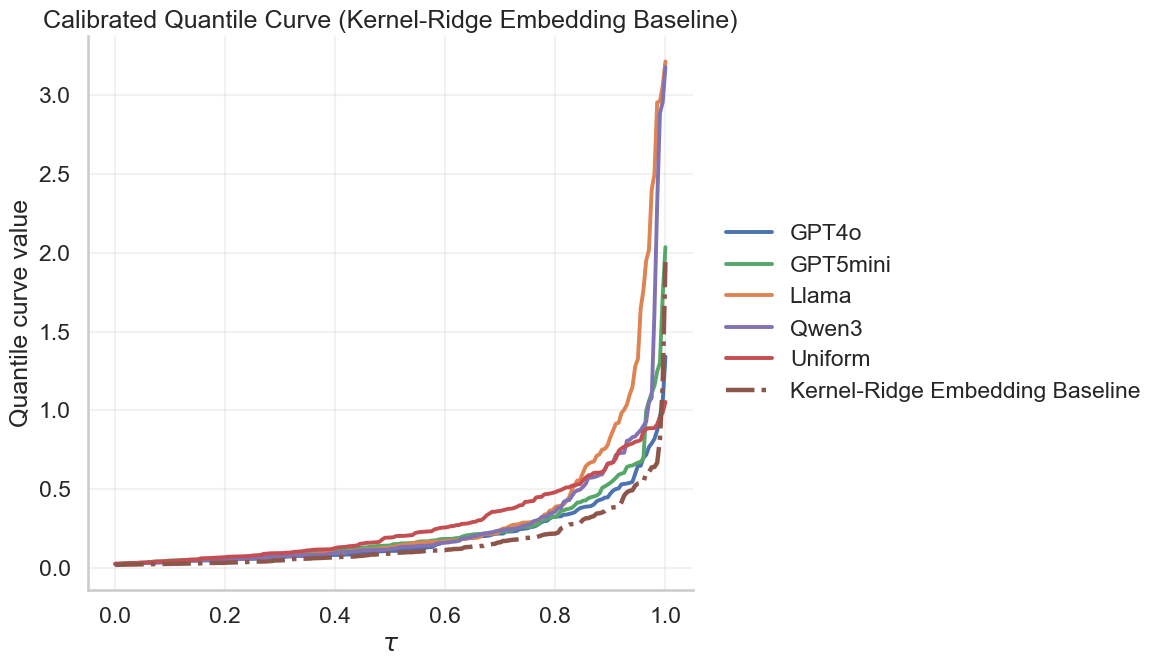

Saved main figure
- worldvalue_quantile/output_embedding_benchmark/worldvalue_benchmark_calibrated_question_embedding_baseline.png
- worldvalue_quantile/figures/worldvalue_benchmark_calibrated_question_embedding_baseline.png


**Supplementary kNN figure.** This plot uses the same question-embedding baseline idea, but forces the learned q predictor to be kNN so we can visually compare local-neighborhood behavior against the kernel-ridge main figure.

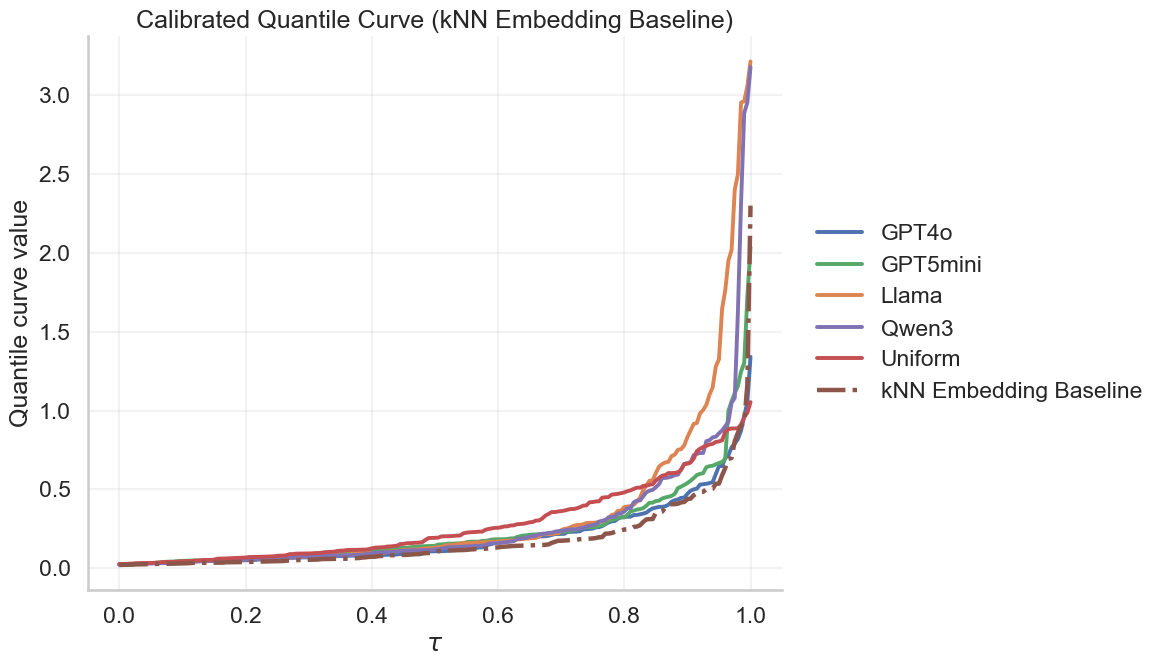

Saved supplementary kNN figure
- worldvalue_quantile/output_embedding_benchmark/worldvalue_benchmark_calibrated_question_embedding_baseline_knn.png
- worldvalue_quantile/figures/worldvalue_benchmark_calibrated_question_embedding_baseline_knn.png


In [11]:
display(
    Markdown(
        "**Main benchmark figure.** "
        "This plot keeps the learned baseline fully question-driven: the added curve is trained only on question embeddings and metadata, then evaluated with the same confidence-set calibrated discrepancy pipeline as the original simulators."
    )
)
fig, ax = plt.subplots(figsize=(12, 7))
for sim_name in [*SIM_ORDER, QUESTION_EMBEDDING_BASELINE_NAME]:
    color = QUESTION_EMBEDDING_COLOR if sim_name == QUESTION_EMBEDDING_BASELINE_NAME else SIM_COLOR_MAP.get(sim_name)
    cal = calibrated_curve_df[calibrated_curve_df["sim"] == sim_name].sort_values("quantile_level")
    if cal.empty:
        continue
    linestyle = QUESTION_EMBEDDING_LINESTYLE if sim_name == QUESTION_EMBEDDING_BASELINE_NAME else "-"
    linewidth = LEARNED_BASELINE_LINEWIDTH if sim_name == QUESTION_EMBEDDING_BASELINE_NAME else 2.8
    ax.plot(
        cal["quantile_level"],
        cal["curve_value"],
        color=color,
        linestyle=linestyle,
        linewidth=linewidth,
        label=sim_name,
    )

ax.set_xlabel(r"$\tau$")
ax.set_ylabel("Quantile curve value")
ax.set_title("Calibrated Quantile Curve (Kernel-Ridge Embedding Baseline)")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
ax.grid(True, alpha=0.25)
plt.tight_layout()
question_embedding_plot_path = OUTPUT_DIR / "worldvalue_benchmark_calibrated_question_embedding_baseline.png"
question_embedding_archive_path = FIGURES_DIR / "worldvalue_benchmark_calibrated_question_embedding_baseline.png"
fig.savefig(question_embedding_plot_path, dpi=220, bbox_inches="tight")
fig.savefig(question_embedding_archive_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved main figure")
for path in [
    question_embedding_plot_path,
    question_embedding_archive_path,
]:
    print(f"- {path.relative_to(REPRO_ROOT)}")

display(
    Markdown(
        "**Supplementary kNN figure.** "
        "This plot uses the same question-embedding baseline idea, but forces the learned q predictor to be kNN so we can visually compare local-neighborhood behavior against the kernel-ridge main figure."
    )
)
fig, ax = plt.subplots(figsize=(12, 7))
for sim_name in [*SIM_ORDER, "kNN Embedding Baseline"]:
    color = QUESTION_EMBEDDING_COLOR if sim_name == "kNN Embedding Baseline" else SIM_COLOR_MAP.get(sim_name)
    cal = question_embedding_knn_curve_df[question_embedding_knn_curve_df["sim"] == sim_name].sort_values("quantile_level")
    if cal.empty:
        continue
    linestyle = QUESTION_EMBEDDING_LINESTYLE if sim_name == "kNN Embedding Baseline" else "-"
    linewidth = LEARNED_BASELINE_LINEWIDTH if sim_name == "kNN Embedding Baseline" else 2.8
    ax.plot(
        cal["quantile_level"],
        cal["curve_value"],
        color=color,
        linestyle=linestyle,
        linewidth=linewidth,
        label=sim_name,
    )

ax.set_xlabel(r"$\tau$")
ax.set_ylabel("Quantile curve value")
ax.set_title("Calibrated Quantile Curve (kNN Embedding Baseline)")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
ax.grid(True, alpha=0.25)
plt.tight_layout()
question_embedding_knn_plot_path = OUTPUT_DIR / "worldvalue_benchmark_calibrated_question_embedding_baseline_knn.png"
question_embedding_knn_archive_path = FIGURES_DIR / "worldvalue_benchmark_calibrated_question_embedding_baseline_knn.png"
fig.savefig(question_embedding_knn_plot_path, dpi=220, bbox_inches="tight")
fig.savefig(question_embedding_knn_archive_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved supplementary kNN figure")
for path in [
    question_embedding_knn_plot_path,
    question_embedding_knn_archive_path,
]:
    print(f"- {path.relative_to(REPRO_ROOT)}")

# Optional XQ / simulator-augmented plot.
# This is kept commented out on purpose because it is not the preferred main baseline figure:
# 1. it uses simulator outputs as input features, so it is not a standalone data-only baseline;
# 2. it depends on the particular simulator bundle included in the feature vector.
#
# display(
#     Markdown(
#         "**Optional simulator-augmented figure.** "
#         "This plot adds the simulator-augmented baseline, which is learned from question features plus simulator-side qhat features."
#     )
# )
# fig, ax = plt.subplots(figsize=(12, 7))
# for sim_name in [*SIM_ORDER, SIMULATOR_AUGMENTED_BASELINE_NAME]:
#     color = SIMULATOR_AUGMENTED_COLOR if sim_name == SIMULATOR_AUGMENTED_BASELINE_NAME else SIM_COLOR_MAP.get(sim_name)
#     cal = calibrated_curve_df[calibrated_curve_df["sim"] == sim_name].sort_values("quantile_level")
#     if cal.empty:
#         continue
#     linestyle = SIMULATOR_AUGMENTED_LINESTYLE if sim_name == SIMULATOR_AUGMENTED_BASELINE_NAME else "-"
#     linewidth = LEARNED_BASELINE_LINEWIDTH if sim_name == SIMULATOR_AUGMENTED_BASELINE_NAME else 2.8
#     ax.plot(
#         cal["quantile_level"],
#         cal["curve_value"],
#         color=color,
#         linestyle=linestyle,
#         linewidth=linewidth,
#         label=sim_name,
#     )
#
# ax.set_xlabel(r"$\tau$")
# ax.set_ylabel("Quantile curve value")
# ax.set_title("Calibrated Quantile Curve (Kernel-Ridge Simulator-Augmented Baseline)")
# ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
# ax.grid(True, alpha=0.25)
# plt.tight_layout()
# simulator_augmented_plot_path = OUTPUT_DIR / "worldvalue_benchmark_calibrated_simulator_augmented_baseline.png"
# simulator_augmented_archive_path = FIGURES_DIR / "worldvalue_benchmark_calibrated_simulator_augmented_baseline.png"
# fig.savefig(simulator_augmented_plot_path, dpi=220, bbox_inches="tight")
# fig.savefig(simulator_augmented_archive_path, dpi=220, bbox_inches="tight")
# plt.show()


### Post-figure benchmark diagnostics

Interpretation guide

- `calibrated`: the adjusted upper curve produced by the confidence-set construction for each simulator, including `Learned baseline`
- `oracle_empirical`: the empirical quantile curve of `loss(p_full, qhat)` using the strongest full-data human target available

Because the learned baseline enters as a simulator-style `q_tilde`, the calibrated-vs-oracle diagnostic is now comparing the same kind of object across all simulator names: a simulator-side output processed through the same discrepancy pipeline.

Crossing guidance

- Crossings between calibrated and oracle empirical curves do not automatically imply a bug.
- Crossings can arise because empirical quantiles fluctuate in finite samples and because the calibrated curve is an upper-envelope construction rather than a pointwise empirical loss curve.
- Broad or systematic crossings should still trigger implementation checks, which is why the oracle empirical curve is retained below as the main diagnostic reference.


In [12]:
def auc_from_curve(alpha, values):
    return float(np.trapz(np.asarray(values, float), np.asarray(alpha, float)))

if question_df["qid"].nunique() != len(question_df):
    raise ValueError("question_df does not have unique qids.")
if benchmark_qhat_df[["qid", "sim"]].duplicated().any():
    dupes = benchmark_qhat_df.loc[benchmark_qhat_df[["qid", "sim"]].duplicated(), ["qid", "sim"]].head()
    raise ValueError(f"benchmark_qhat_df has duplicate (qid, sim) rows: {dupes.to_dict('records')}")

qids_question = set(question_df["qid"])
qids_target = set(selected_target_df.loc[selected_target_df["human_target"].notna(), "qid"])
qids_question_embedding = set(question_embedding_pred_df["qid"])
qids_simulator_augmented = set(simulator_augmented_pred_df["qid"])
qids_qhat = set(benchmark_qhat_df["qid"])
if not (qids_question == qids_target == qids_question_embedding == qids_simulator_augmented == qids_qhat):
    raise ValueError(
        "Perfect qid alignment failed across question_df, selected_target_df, learned baseline predictions, and benchmark_qhat_df."
    )

if not np.isfinite(question_df["human_target"]).all():
    raise ValueError("Non-finite values found in the selected full-data human target.")
if not np.isfinite(benchmark_qhat_df["qhat"]).all():
    raise ValueError("Non-finite values found in simulator qhat values.")

for obj_name, arr in {
    "human_target": question_df["human_target"].to_numpy(float),
    "question_embedding_qtilde": question_embedding_pred_df["qtilde_question_embedding"].to_numpy(float),
    "simulator_augmented_qtilde": simulator_augmented_pred_df["qtilde_simulator_augmented"].to_numpy(float),
    "qhat": benchmark_qhat_df["qhat"].to_numpy(float),
    "oracle_emp_delta": oracle_emp_base["oracle_emp_delta"].to_numpy(float),
    "calibrated_delta": calibrated_delta_df["delta"].to_numpy(float),
}.items():
    if not np.isfinite(arr).all():
        raise ValueError(f"Non-finite curve inputs found in {obj_name}.")

if (question_df["human_target"].min() < -1.000001) or (question_df["human_target"].max() > 1.000001):
    raise ValueError("Selected full-data human target is outside the expected [-1, 1] scale.")
if (benchmark_qhat_df["qhat"].min() < -1.000001) or (benchmark_qhat_df["qhat"].max() > 1.000001):
    raise ValueError("Simulator qhat is outside the expected [-1, 1] scale.")

oracle_comparison_curve_df = pd.concat(
    [
        calibrated_curve_df,
        oracle_curve_df,
    ],
    ignore_index=True,
)
oracle_comparison_curve_df.to_csv(OUTPUT_DIR / "oracle_comparison_curve_dataframe.csv", index=False)

oracle_crossing_rows = []
for sim_name in [*SIM_ORDER, QUESTION_EMBEDDING_BASELINE_NAME, SIMULATOR_AUGMENTED_BASELINE_NAME]:
    cal = calibrated_curve_df[calibrated_curve_df["sim"] == sim_name][["quantile_level", "curve_value"]].rename(columns={"curve_value": "calibrated"})
    oracle = oracle_curve_df[oracle_curve_df["sim"] == sim_name][["quantile_level", "curve_value"]].rename(columns={"curve_value": "oracle_empirical"})
    merged = cal.merge(oracle, on="quantile_level", how="inner")
    if len(merged) != len(TAU_GRID):
        raise ValueError(f"Curve alignment failed for {sim_name}.")

    oracle_crossing_rows.append(
        {
            "sim": sim_name,
            "auc_calibrated": auc_from_curve(merged["quantile_level"], merged["calibrated"]),
            "auc_oracle_empirical": auc_from_curve(merged["quantile_level"], merged["oracle_empirical"]),
            "frac_oracle_empirical_gt_calibrated": float(np.mean(merged["oracle_empirical"] > merged["calibrated"])),
        }
    )

oracle_crossing_summary_df = pd.DataFrame(oracle_crossing_rows)
oracle_crossing_summary_df["suspicious_oracle_gt_calibrated_broad"] = (
    oracle_crossing_summary_df["frac_oracle_empirical_gt_calibrated"] > 0.5
)
oracle_crossing_summary_df.to_csv(OUTPUT_DIR / "oracle_crossing_summary.csv", index=False)

mean_oracle_gt_cal = float(oracle_crossing_summary_df["frac_oracle_empirical_gt_calibrated"].mean())
suspicious_count = int(oracle_crossing_summary_df["suspicious_oracle_gt_calibrated_broad"].sum())
question_embedding_summary = oracle_crossing_summary_df[
    oracle_crossing_summary_df["sim"] == QUESTION_EMBEDDING_BASELINE_NAME
].iloc[0]
simulator_augmented_summary = oracle_crossing_summary_df[
    oracle_crossing_summary_df["sim"] == SIMULATOR_AUGMENTED_BASELINE_NAME
].iloc[0]

if mean_oracle_gt_cal < 0.5:
    oracle_vs_cal_message = "The calibrated curves are mostly above the oracle empirical curves, which is the expected qualitative pattern."
else:
    oracle_vs_cal_message = "The oracle empirical curves are broadly above calibrated, which suggests an indexing or implementation mismatch and should be investigated."

learned_baseline_message = (
    f"The question-embedding baseline enters the same calibrated pipeline as the other simulators; "
    f"its calibrated AUC is {question_embedding_summary['auc_calibrated']:.4f}. "
    f"The simulator-augmented baseline also enters the same calibrated pipeline; "
    f"its calibrated AUC is {simulator_augmented_summary['auc_calibrated']:.4f}."
)
suspicious_message = (
    "No suspicious broad oracle-vs-calibrated crossing pattern was detected."
    if suspicious_count == 0
    else f"{suspicious_count} simulator(s) show a broad oracle empirical crossing above calibrated and should be checked more closely."
)

display(Markdown("### Oracle comparison summary"))
display(oracle_crossing_summary_df)
display(
    Markdown(
        "\n".join(
            [
                "### Concise conclusion",
                f"- {oracle_vs_cal_message}",
                f"- {learned_baseline_message}",
                f"- {suspicious_message}",
            ]
        )
    )
)


### Oracle comparison summary

,sim,auc_calibrated,auc_oracle_empirical,frac_oracle_empirical_gt_calibrated,suspicious_oracle_gt_calibrated_broad
0,GPT4o,0.195768,0.106617,0.0,False
1,GPT5mini,0.232504,0.133655,0.0,False
2,Llama,0.327685,0.210970,0.0,False
3,Qwen3,0.268277,0.166327,0.0,False
4,Uniform,0.276700,0.166457,0.0,False
5,Kernel-Ridge Embedding Baseline,0.156185,0.084187,0.0,False
6,Kernel-Ridge Simulator-Augmented Baseline,0.082912,0.035841,0.0,False


### Concise conclusion
- The calibrated curves are mostly above the oracle empirical curves, which is the expected qualitative pattern.
- The question-embedding baseline enters the same calibrated pipeline as the other simulators; its calibrated AUC is 0.1562. The simulator-augmented baseline also enters the same calibrated pipeline; its calibrated AUC is 0.0829.
- No suspicious broad oracle-vs-calibrated crossing pattern was detected.

### Diagnostics and summary tables

These checks are here to distinguish genuine benchmark behavior from alignment or scaling bugs.


In [13]:
def auc_from_curve(alpha, values):
    return float(np.trapz(np.asarray(values, float), np.asarray(alpha, float)))

def cvar_like_from_curve(alpha, values, alpha0=0.90):
    alpha = np.asarray(alpha, float)
    values = np.asarray(values, float)
    mask = alpha >= alpha0
    if mask.sum() < 2:
        return np.nan
    return float(np.trapz(values[mask], alpha[mask]) / max(1e-12, (alpha[mask][-1] - alpha[mask][0])))

alignment_checks = pd.DataFrame(
    [
        {"check": "retained_qids", "n_unique": len(retained_questions)},
        {"check": "question_df_qids", "n_unique": int(question_df["qid"].nunique())},
        {"check": "selected_human_target_qids", "n_unique": int(question_df["human_target"].notna().sum())},
        {"check": "common_qids_calibrated", "n_unique": len(common_qids)},
        {"check": "benchmark_qhat_qids", "n_unique": int(benchmark_qhat_df["qid"].nunique())},
        {"check": "question_embedding_qids", "n_unique": int(question_embedding_pred_df["qid"].nunique())},
        {"check": "simulator_augmented_qids", "n_unique": int(simulator_augmented_pred_df["qid"].nunique())},
        {"check": "qid_sets_all_match", "n_unique": int(
            (set(retained_questions) == set(question_df["qid"]) == set(common_qids) == set(benchmark_qhat_df["qid"]))
        )},
    ]
)

scale_checks_df = pd.DataFrame(
    [
        {
            "object": "human_target",
            "min": float(np.nanmin(question_df["human_target"])),
            "max": float(np.nanmax(question_df["human_target"])),
            "mean": float(np.nanmean(question_df["human_target"])),
        },
        {
            "object": "qhat_all_sims",
            "min": float(np.nanmin(benchmark_qhat_df["qhat"])),
            "max": float(np.nanmax(benchmark_qhat_df["qhat"])),
            "mean": float(np.nanmean(benchmark_qhat_df["qhat"])),
        },
        {
            "object": "qtilde_question_embedding",
            "min": float(np.nanmin(question_embedding_pred_df["qtilde_question_embedding"])),
            "max": float(np.nanmax(question_embedding_pred_df["qtilde_question_embedding"])),
            "mean": float(np.nanmean(question_embedding_pred_df["qtilde_question_embedding"])),
        },
        {
            "object": "qtilde_simulator_augmented",
            "min": float(np.nanmin(simulator_augmented_pred_df["qtilde_simulator_augmented"])),
            "max": float(np.nanmax(simulator_augmented_pred_df["qtilde_simulator_augmented"])),
            "mean": float(np.nanmean(simulator_augmented_pred_df["qtilde_simulator_augmented"])),
        },
    ]
)

predictor_category_df = pd.concat(
    [
        question_embedding_pred_df.assign(baseline_variant="question_embedding", abs_error=question_embedding_pred_df["abs_error"], sq_error=question_embedding_pred_df["sq_error"])[["baseline_variant", "category", "qid", "abs_error", "sq_error"]],
        simulator_augmented_pred_df.assign(baseline_variant="simulator_augmented_optional", abs_error=simulator_augmented_pred_df["abs_error"], sq_error=simulator_augmented_pred_df["sq_error"])[["baseline_variant", "category", "qid", "abs_error", "sq_error"]],
    ],
    ignore_index=True,
)
predictor_category_df = (
    predictor_category_df.groupby(["baseline_variant", "category"], dropna=False)
    .agg(
        n_qids=("qid", "count"),
        rmse=("sq_error", lambda s: float(np.sqrt(np.mean(s)))),
        mae=("abs_error", "mean"),
    )
    .reset_index()
    .sort_values(["baseline_variant", "rmse", "n_qids"], ascending=[True, False, False])
)
predictor_category_df.to_csv(OUTPUT_DIR / "predictor_category_summary.csv", index=False)

discrepancy_detail_df = (
    calibrated_delta_df
    .merge(benchmark_qhat_df[["qid", "sim", "qhat", "k_used"]], on=["qid", "sim"], how="left")
    .merge(oracle_emp_base[["qid", "sim", "oracle_emp_delta"]], on=["qid", "sim"], how="left")
)
discrepancy_summary_df = (
    discrepancy_detail_df.groupby("sim", dropna=False)
    .agg(
        n_qids=("qid", "nunique"),
        mean_calibrated_delta=("delta", "mean"),
        median_calibrated_delta=("delta", "median"),
        mean_oracle_emp_delta=("oracle_emp_delta", "mean"),
        mean_qhat=("qhat", "mean"),
        min_k_used=("k_used", "min"),
        max_k_used=("k_used", "max"),
    )
    .reset_index()
    .sort_values("sim")
)
discrepancy_summary_df.to_csv(OUTPUT_DIR / "discrepancy_summary.csv", index=False)

curve_summary_rows = []
for sim_name in [*SIM_ORDER, QUESTION_EMBEDDING_BASELINE_NAME, SIMULATOR_AUGMENTED_BASELINE_NAME]:
    cal = calibrated_curve_df[calibrated_curve_df["sim"] == sim_name].sort_values("quantile_level")
    oracle = oracle_curve_df[oracle_curve_df["sim"] == sim_name].sort_values("quantile_level")
    if cal.empty or oracle.empty:
        continue
    curve_summary_rows.append(
        {
            "sim": sim_name,
            "human_target_source": selected_target_source,
            "embedding_source": embedding_source,
            "bar_gamma_overall": float(gamma_summary["bar_gamma_overall"]),
            "alpha_min_calibrated": float(alpha_calibrated.min()),
            "auc_calibrated_shifted_alpha": auc_from_curve(cal["quantile_level"], cal["curve_value"]),
            "auc_oracle_empirical": auc_from_curve(oracle["quantile_level"], oracle["curve_value"]),
            "cvar_calibrated_shifted_alpha": cvar_like_from_curve(cal["quantile_level"], cal["curve_value"], alpha0=TAIL_ALPHA0),
            "cvar_oracle_empirical": cvar_like_from_curve(oracle["quantile_level"], oracle["curve_value"], alpha0=TAIL_ALPHA0),
        }
    )

curve_summary_df = pd.DataFrame(curve_summary_rows)
curve_summary_df.to_csv(OUTPUT_DIR / "curve_summary.csv", index=False)

display(Markdown("### Alignment checks"))
display(alignment_checks)
display(Markdown("### Dataset selection"))
display(target_selection_df)
display(full_target_consistency_summary)
display(Markdown("### Scale checks"))
display(scale_checks_df)
display(Markdown("### Predictor summary"))
display(predictor_summary_df)
display(Markdown("### Model-family comparison"))
display(family_comparison_df)
display(Markdown("### Discrepancy summary"))
display(discrepancy_summary_df)
display(Markdown("### Curve summary"))
display(curve_summary_df)

keep_output_files = {
    "question_feature_dataframe.csv",
    "simulator_feature_qhat_dataframe.csv",
    "human_target_source_summary.csv",
    "human_target_consistency_summary.csv",
    "question_embedding_baseline_qtilde_predictions.csv",
    "simulator_augmented_baseline_qtilde_predictions.csv",
    "question_embedding_knn_qtilde_predictions.csv",
    "predictor_summary.csv",
    "embedding_baseline_method_comparison.csv",
    "crossfit_fold_selection_question_embedding.csv",
    "crossfit_fold_selection_simulator_augmented.csv",
    "crossfit_fold_selection_question_embedding_knn.csv",
    "benchmark_qhat_dataframe.csv",
    "question_embedding_qhat_alignment.csv",
    "calibrated_delta_dataframe.csv",
    "curve_dataframe.csv",
    "discrepancy_summary.csv",
    "curve_summary.csv",
}

removed_artifacts = []
for path in sorted(OUTPUT_DIR.iterdir()):
    if not path.is_file():
        continue
    if path.suffix.lower() not in {".csv", ".png"}:
        continue
    if path.name in keep_output_files:
        continue
    path.unlink()
    removed_artifacts.append(path)

print("Saved minimal artifacts")
for path in [
    OUTPUT_DIR / "question_feature_dataframe.csv",
    OUTPUT_DIR / "simulator_feature_qhat_dataframe.csv",
    OUTPUT_DIR / "human_target_source_summary.csv",
    OUTPUT_DIR / "human_target_consistency_summary.csv",
    OUTPUT_DIR / "question_embedding_baseline_qtilde_predictions.csv",
    OUTPUT_DIR / "simulator_augmented_baseline_qtilde_predictions.csv",
    OUTPUT_DIR / "question_embedding_knn_qtilde_predictions.csv",
    OUTPUT_DIR / "predictor_summary.csv",
    OUTPUT_DIR / "embedding_baseline_method_comparison.csv",
    OUTPUT_DIR / "crossfit_fold_selection_question_embedding.csv",
    OUTPUT_DIR / "crossfit_fold_selection_simulator_augmented.csv",
    OUTPUT_DIR / "crossfit_fold_selection_question_embedding_knn.csv",
    OUTPUT_DIR / "benchmark_qhat_dataframe.csv",
    OUTPUT_DIR / "question_embedding_qhat_alignment.csv",
    OUTPUT_DIR / "calibrated_delta_dataframe.csv",
    OUTPUT_DIR / "curve_dataframe.csv",
    OUTPUT_DIR / "discrepancy_summary.csv",
    OUTPUT_DIR / "curve_summary.csv",
    question_embedding_archive_path,
    question_embedding_knn_archive_path,
]:
    print(f"- {path.relative_to(REPRO_ROOT)}")

if removed_artifacts:
    print("Removed overlapping or legacy artifacts")
    for path in removed_artifacts:
        print(f"- {path.relative_to(REPRO_ROOT)}")


### Alignment checks

,check,n_unique
0,retained_qids,235
1,question_df_qids,235
2,selected_human_target_qids,235
3,common_qids_calibrated,235
4,benchmark_qhat_qids,235
5,question_embedding_qids,235
6,simulator_augmented_qids,235
7,qid_sets_all_match,1


### Dataset selection

,candidate_name,n_qids_with_target,min_n_valid,max_n_valid
0,full_raw_responses,235,68524.0,96066.0
1,full_summary_aggregate,235,68524.0,96066.0
2,actual_smaller_sample,235,350.0,500.0


,selected_target_source,max_abs_mean_diff_raw_vs_summary,mean_abs_mean_diff_raw_vs_summary
0,actual_smaller_sample,0.0,0.0


...

### Discrepancy summary

,sim,n_qids,mean_calibrated_delta,median_calibrated_delta,mean_oracle_emp_delta,mean_qhat,min_k_used,max_k_used
0,GPT4o,235,0.174544,0.085650,0.106797,0.028001,200.0,200.0
1,GPT5mini,235,0.207894,0.118217,0.135012,0.070417,200.0,200.0
2,Kernel-Ridge Embedding Baseline,235,0.141109,0.072024,0.086262,-0.009109,1.0,1.0
3,Kernel-Ridge Simulator-Augmented Baseline,235,0.076927,0.041028,0.037643,-0.005285,1.0,1.0
4,Llama,235,0.291464,0.106598,0.211125,0.120474,200.0,200.0
5,Qwen3,235,0.240597,0.103144,0.166025,0.057737,200.0,200.0
6,Uniform,235,0.244633,0.138752,0.166615,0.006911,200.0,200.0


### Curve summary

,sim,human_target_source,embedding_source,bar_gamma_overall,alpha_min_calibrated,auc_calibrated_shifted_alpha,auc_oracle_empirical,cvar_calibrated_shifted_alpha,cvar_oracle_empirical
0,GPT4o,actual_smaller_sample,cached_openai_embeddings:text-embedding-3-small,0.874008,0.125992,0.195768,0.106617,0.683575,0.482555
1,GPT5mini,actual_smaller_sample,cached_openai_embeddings:text-embedding-3-small,0.874008,0.125992,0.232504,0.133655,0.872334,0.662757
2,Llama,actual_smaller_sample,cached_openai_embeddings:text-embedding-3-small,0.874008,0.125992,0.327685,0.210970,1.693723,1.350411
3,Qwen3,actual_smaller_sample,cached_openai_embeddings:text-embedding-3-small,0.874008,0.125992,0.268277,0.166327,1.212816,0.973149
4,Uniform,actual_smaller_sample,cached_openai_embeddings:text-embedding-3-small,0.874008,0.125992,0.276700,0.166457,0.826703,0.628303
5,Kernel-Ridge Embedding Baseline,actual_smaller_sample,cached_openai_embeddings:text-embedding-3-small,0.874008,0.125992,0.156185,0.084187,0.597274,0.433671
6,Kernel-Ridge Simulator-Augmented Baseline,actual_smaller_sample,cached_openai_embeddings:text-embedding-3-small,0.874008,0.125992,0.082912,0.035841,0.316804,0.209042


Saved minimal artifacts
- worldvalue_quantile/output_embedding_benchmark/question_feature_dataframe.csv
- worldvalue_quantile/output_embedding_benchmark/simulator_feature_qhat_dataframe.csv
- worldvalue_quantile/output_embedding_benchmark/human_target_source_summary.csv
- worldvalue_quantile/output_embedding_benchmark/human_target_consistency_summary.csv
- worldvalue_quantile/output_embedding_benchmark/question_embedding_baseline_qtilde_predictions.csv
- worldvalue_quantile/output_embedding_benchmark/simulator_augmented_baseline_qtilde_predictions.csv
- worldvalue_quantile/output_embedding_benchmark/question_embedding_knn_qtilde_predictions.csv
- worldvalue_quantile/output_embedding_benchmark/predictor_summary.csv
- worldvalue_quantile/output_embedding_benchmark/embedding_baseline_method_comparison.csv
- worldvalue_quantile/output_embedding_benchmark/crossfit_fold_selection_question_embedding.csv
- worldvalue_quantile/output_embedding_benchmark/crossfit_fold_selection_simulator_augment